In [1]:
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=FutureWarning) # don't warn us about future package conflicts

In [2]:
import pandas as pd
import xarray as xr
import numpy as np
from datetime import datetime
from healpix_plot import get_listed_colormap, get_diverging_colormap

In [3]:
# Create a dictionary mapping variable names to their dataframes
statvar = 'mean'; minduration = 6; timerange=(-24,10);
ti = '2020-02-01'; tf='2020-08-31'


In [4]:
out_dir = '/pscratch/sd/p/paccini/temp/hackathon/'

In [5]:
filtered_df_q2m_um = pd.read_pickle(out_dir+'filtered_df_q2m_um.pkl')
filtered_df_swind_um = pd.read_pickle(out_dir+'filtered_df_swind_um.pkl')
filtered_df_prw_um = pd.read_pickle(out_dir+'filtered_df_prw_um.pkl')
filtered_df_rh500_um = pd.read_pickle(out_dir+'filtered_df_rh500_um.pkl')
filtered_df_rh850_um = pd.read_pickle(out_dir+'filtered_df_rh850_um.pkl')
filtered_df_omega500_um = pd.read_pickle(out_dir+'filtered_df_omega500_um.pkl')
filtered_df_omega850_um = pd.read_pickle(out_dir+'filtered_df_omega850_um.pkl')

In [6]:
filtered_df_q2m_scream = pd.read_pickle('filtered_df_q2m_scream.pkl')
filtered_df_prw_scream = pd.read_pickle('filtered_df_prw_scream.pkl')
filtered_df_rh500_scream = pd.read_pickle('filtered_df_rh500_scream.pkl')
filtered_df_rh850_scream = pd.read_pickle('filtered_df_rh850_scream.pkl')
filtered_df_omega850_scream = pd.read_pickle('filtered_df_omega850_scream.pkl')
filtered_df_omega500_scream = pd.read_pickle('filtered_df_omega500_scream.pkl')

In [7]:
filtered_df_q2m_icon = pd.read_pickle('filtered_df_q2m_icon.pkl')
filtered_df_prw_icon = pd.read_pickle('filtered_df_prw_icon.pkl')

In [8]:
out_dir = '/pscratch/sd/p/paccini/temp/hackathon/'
filtered_df_rh500_icon = pd.read_pickle(out_dir+'filtered_df_rh500_icon.pkl')
filtered_df_rh850_icon = pd.read_pickle(out_dir+'filtered_df_rh850_icon.pkl')
filtered_df_omega500_icon = pd.read_pickle(out_dir+'filtered_df_omega500_icon.pkl')
filtered_df_omega850_icon = pd.read_pickle(out_dir+'filtered_df_omega850_icon.pkl')

In [9]:
filtered_df_rh500_icon = filtered_df_rh500_icon.rename(columns={'start_basetime_mcs': 'start_basetime'})
filtered_df_rh850_icon = filtered_df_rh850_icon.rename(columns={'start_basetime_mcs': 'start_basetime'})
filtered_df_omega500_icon = filtered_df_omega500_icon.rename(columns={'start_basetime_mcs': 'start_basetime'})
filtered_df_omega850_icon = filtered_df_omega850_icon.rename(columns={'start_basetime_mcs': 'start_basetime'})

In [10]:
out_dir = '/pscratch/sd/p/paccini/temp/hackathon/'
filtered_df_prw_ifs = pd.read_pickle(out_dir+'filtered_df_prw_ifs.pkl')
filtered_df_rh500_ifs = pd.read_pickle(out_dir+'filtered_df_rh500_ifs.pkl')
filtered_df_rh850_ifs = pd.read_pickle(out_dir+'filtered_df_rh850_ifs.pkl')
filtered_df_omega500_ifs = pd.read_pickle(out_dir+'filtered_df_omega500_ifs.pkl')
filtered_df_omega850_ifs = pd.read_pickle(out_dir+'filtered_df_omega850_ifs.pkl')

In [11]:
filtered_df_prw_ifs.columns

Index(['track', 'radius', 'matched_time', 'mean', 'median', 'min', 'max',
       'std', 'count', 'valid_count', 'time_offset_hours',
       'mean_land_fraction_track', 'time_index', 'track_duration',
       'mcs_duration', 'start_split_cloudnumber', 'start_basetime_mcs', 'area',
       'total_rain', 'mcs_status'],
      dtype='object')

In [12]:
filtered_df_prw_ifs = filtered_df_prw_ifs.rename(columns={'start_basetime_mcs': 'start_basetime'})
filtered_df_rh500_ifs = filtered_df_rh500_ifs.rename(columns={'start_basetime_mcs': 'start_basetime'})
filtered_df_rh850_ifs = filtered_df_rh850_ifs.rename(columns={'start_basetime_mcs': 'start_basetime'})
filtered_df_omega500_ifs = filtered_df_omega500_ifs.rename(columns={'start_basetime_mcs': 'start_basetime'})
filtered_df_omega850_ifs = filtered_df_omega850_ifs.rename(columns={'start_basetime_mcs': 'start_basetime'})

In [13]:
filtered_df_prw_era5 = pd.read_pickle('/pscratch/sd/p/paccini/temp/hackathon/filtered_df_prw_era5_2020.pkl')
filtered_df_rh500_era5 = pd.read_pickle('/pscratch/sd/p/paccini/temp/hackathon/filtered_df_rh500_era5_2020.pkl')
# filtered_df_w850_era5 = pd.read_pickle('/pscratch/sd/p/paccini/temp/hackathon/filtered_df_w850mb_era5_2020.pkl')
filtered_df_w500_era5 = pd.read_pickle('/pscratch/sd/p/paccini/temp/hackathon/filtered_df_w500mb_era5_2020.pkl')

In [14]:
# filtered_df_rh850_era5 = pd.read_pickle('/pscratch/sd/p/paccini/temp/hackathon/filtered_df_rh850_era5_2020.pkl')


In [15]:
filtered_df_rh850_era5 = pd.read_pickle('/pscratch/sd/p/paccini/temp/hackathon/new_filtered_df_rh850mb_era5_2020.pkl')
filtered_df_w850_era5 = pd.read_pickle('/pscratch/sd/p/paccini/temp/hackathon/new_filtered_df_w850mb_era5_2020.pkl')

In [18]:
filtered_df_prw_era5['time_offset_hours'] = filtered_df_prw_era5['rel_time_hours']

In [19]:
filtered_df_rh850_era5['time_offset_hours'] = filtered_df_rh850_era5['rel_time_hours']
filtered_df_rh500_era5['time_offset_hours'] = filtered_df_rh500_era5['rel_time_hours']
filtered_df_w850_era5['time_offset_hours'] = filtered_df_w850_era5['rel_time_hours']
filtered_df_w500_era5['time_offset_hours'] = filtered_df_w500_era5['rel_time_hours']

In [20]:
filtered_df_rh500_scream['mean'] = filtered_df_rh500_scream['mean']*100
filtered_df_rh850_scream['mean'] = filtered_df_rh850_scream['mean']*100

In [21]:
## read filtered track ids
odir = '/pscratch/sd/p/paccini/temp/hackathon/filtered_mcs_track_ids/'
df_trop_obs = pd.read_pickle(odir+'df_trop_obs.pkl')
df_trop_icon = pd.read_pickle(odir+'df_trop_icon.pkl')
df_trop_scream = pd.read_pickle(odir+'df_trop_scream.pkl')
df_trop_um = pd.read_pickle(odir+'df_trop_um.pkl')
df_trop_ifs = pd.read_pickle(odir+'df_trop_ifs.pkl')

In [50]:
df_trop_obs_1ts = pd.read_pickle(odir+'df_trop_obs_1timestp.pkl')
df_trop_icon_1ts = pd.read_pickle(odir+'df_trop_icon_1timestp.pkl')
df_trop_scream_1ts = pd.read_pickle(odir+'df_trop_scream_1timestp.pkl')
df_trop_um_1ts = pd.read_pickle(odir+'df_trop_um_1timestp.pkl')
df_trop_ifs_1ts = pd.read_pickle(odir+'df_trop_ifs_1timestp.pkl')

In [22]:
filtered_df_rh500_era5[filtered_df_rh500_era5['track'].isin(df_trop_obs['track_id'])].track.nunique()

4535

In [23]:
import tools_mcs_stats
import importlib
importlib.reload(tools_mcs_stats)

<module 'tools_mcs_stats' from '/global/cfs/cdirs/wcm_code/lpaccini/scripts/hackathon/tools_mcs_stats.py'>

In [24]:
filtered_df_prw_scream = filtered_df_prw_scream.drop_duplicates().reset_index(drop=True)
filtered_df_omega850_scream = filtered_df_omega850_scream.drop_duplicates().reset_index(drop=True)
filtered_df_rh500_scream = filtered_df_rh500_scream.drop_duplicates().reset_index(drop=True)
filtered_df_rh850_scream = filtered_df_rh850_scream.drop_duplicates().reset_index(drop=True)

In [25]:
def get_vars_per_track(df):
    ## add vars per track
    df['all_rain'] = df.groupby('track')['total_rain'].transform('sum')
    df['mean_rain'] = df.groupby('track')['total_rain'].transform('mean')
    df['all_area'] = df.groupby('track')['area'].transform('sum')
    return(df)

In [26]:
def get_composite_data(df_1, df_2, var1= 'mean', ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',varbins=10, key_cols= ['track', 'radius', 'matched_time', 'start_basetime',
            'time_offset_hours', 'latitude', 'longitude'],value_feature = 'mean_rain'):
    df_1 = df_1.rename(columns={var1: ren_var1})
    df_2 = df_2.rename(columns={var2: ren_var2})
    df_merged = df_1.merge(df_2[key_cols + [ren_var2]], on=key_cols, how='left')    

    feature_1 = ren_var1; 
    bin_labels_1 = [f'Bin {i+1}' for i in range(varbins)]
    df_merged[f'{feature_1}_bin'] = pd.qcut(df_merged[feature_1], q=varbins, labels=bin_labels_1, duplicates='drop')
    bins_for_labels_1 = pd.qcut(df_merged[feature_1], q=varbins, duplicates='drop').cat.categories
    
    feature_2 = ren_var2;
    bin_labels_2 = [f'Bin {i+1}' for i in range(varbins)]
    df_merged[f'{feature_2}_bin'] = pd.qcut(df_merged[feature_2], q=varbins, labels=bin_labels_2, duplicates='drop')
    bins_for_labels_2 = pd.qcut(df_merged[feature_2], q=varbins, duplicates='drop').cat.categories

    
    composite_data = df_merged.groupby([f'{feature_1}_bin',f'{feature_2}_bin'])[value_feature].mean().unstack()
    return(composite_data,value_feature, feature_1,feature_2)

In [93]:
def get_adaptive_composite_data(df_1, df_2, min_samples_per_bin=20, var1= 'mean', ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',**kwargs):
    # Start with your current approach but check bin sizes
    composite_data, value_feature, feature_1, feature_2 = get_composite_data(df_1, df_2, **kwargs)
    
    # Count samples per bin
    df_merged = df_1.merge(df_2[key_cols + [ren_var2]], on=key_cols, how='left')
    bin_counts = df_merged.groupby([f'{feature_1}_bin', f'{feature_2}_bin']).size().unstack(fill_value=0)
    
    # Identify bins with insufficient data
    sparse_bins = bin_counts < min_samples_per_bin
    
    return composite_data, bin_counts, sparse_bins, value_feature, feature_1, feature_2

In [68]:
def create_composite_grid(df_1, df_2, var1='mean', ren_var1='mean_rh850',
                          var2='mean', ren_var2='mean_omega850', varbins=5,
                          key_cols=['track', 'radius', 'matched_time'],
                          value_feature='mean_rain'):
    """
    Merges two dataframes and creates 2D composite grids for both the mean and
    the count of a value feature, based on bins of two other features.
    """
    # Prepare dataframes by renaming and merging
    df_1 = df_1.rename(columns={var1: ren_var1})
    df_2 = df_2.rename(columns={var2: ren_var2})
    # Ensure value_feature is in the first dataframe for the merge
    merge_cols_df1 = key_cols + [ren_var1, value_feature]
    df_merged = df_1[merge_cols_df1].merge(df_2[key_cols + [ren_var2]], on=key_cols, how='inner')
    df_merged.dropna(subset=[ren_var1, ren_var2, value_feature], inplace=True)

    # Bin the two primary features (e.g., humidity and vertical velocity)
    df_merged[f'{ren_var1}_bin'] = pd.qcut(df_merged[ren_var1], q=varbins, labels=False, duplicates='drop')
    df_merged[f'{ren_var2}_bin'] = pd.qcut(df_merged[ren_var2], q=varbins, labels=False, duplicates='drop')

    # Group by the new bins and calculate both mean and count
    composite_stats = df_merged.groupby([f'{ren_var1}_bin', f'{ren_var2}_bin'])[value_feature].agg(['mean', 'count'])

    # Unstack to create the 2D grids
    composite_mean = composite_stats['mean'].unstack()
    composite_count = composite_stats['count'].unstack()

    # Get bin edges for labeling the plot axes later
    # We'll use the original qcut results for this
    mean_bin_edges_1 = pd.qcut(df_merged[ren_var1], q=varbins, duplicates='drop').cat.categories
    mean_bin_edges_2 = pd.qcut(df_merged[ren_var2], q=varbins, duplicates='drop').cat.categories
    
    # Store metadata for plotting
    plot_info = {
        'value_feature': value_feature,
        'feature_1': ren_var1,
        'feature_2': ren_var2,
        'bin_edges_1': mean_bin_edges_1,
        'bin_edges_2': mean_bin_edges_2
    }
    
    return composite_mean, composite_count, plot_info

In [69]:
def multi_resolution_analysis(df_1, df_2, bin_sizes=[3, 5, 7, 10]):
    results = {}
    for n_bins in bin_sizes:
        composite, counts, sparse, val_feat, feat1, feat2 = get_adaptive_composite_data(
            df_1, df_2, varbins=n_bins
        )
        # Calculate percentage of well-populated bins
        well_populated = (counts >= 20).sum().sum() / (n_bins * n_bins) * 100
        results[n_bins] = {
            'composite': composite,
            'coverage': well_populated,
            'total_samples': counts.sum().sum()
        }
    return results

In [27]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator

In [28]:
import mycolors as mycmap

In [29]:
def get_key_stages(df):
    results = []

    for track_id, g in df.groupby("track"):
        g = g.sort_values("time_offset_hours")

        # 1) Mature state = max total_rain
        mature_idx = g["total_rain"].idxmax()
        mature_row = g.loc[mature_idx]
        mature_time = mature_row["time_offset_hours"]

        # 2) Midpoint between 0 and mature
        if (g["time_offset_hours"] >= 0).any():
            start_time = g[g["time_offset_hours"] >= 0]["time_offset_hours"].min()
        else:
            # if no time_offset >=0 exists, skip
            continue
        mid1_time = (start_time + mature_time) / 2
        mid1_row = g.iloc[(g["time_offset_hours"] - mid1_time).abs().argmin()]

        # 3) Midpoint between mature and termination
        end_time = g["time_offset_hours"].max()
        mid2_time = (mature_time + end_time) / 2
        mid2_row = g.iloc[(g["time_offset_hours"] - mid2_time).abs().argmin()]

        # Collect rows
        results.extend([
            {**mature_row.to_dict(), "stage": "mature"},
            {**mid1_row.to_dict(), "stage": "growing"},
            {**mid2_row.to_dict(), "stage": "decaying"},
        ])

    return pd.DataFrame(results)

In [37]:
def plot_bivariate(composite,value_feature, feature_1,feature_2,
                   figs =(8,6),cmap = mycmap.whiteTOblueTOgreen, vmin=None,vmax=None,nbins=20, normalize=True,qtile_norm=True):
    
    fig, ax = plt.subplots(figsize=figs)
    cmap = plt.get_cmap(cmap); 
    
    data = composite.values
    if normalize:
        if qtile_norm:
            data = (data - np.nanquantile(data,0.1)) / (np.nanquantile(data,0.9) - np.nanquantile(data,0.1))
        else:
            data = (data - np.nanmin(data)) / (np.nanmax(data) - np.nanmin(data))
        
        vmin, vmax = 0, 1  # overwrite   
    else:
        if vmin is None: vmin = np.nanmin(data)
        if vmax is None: vmax = np.nanmax(data)
  
    levels = MaxNLocator(nbins=nbins).tick_values(vmin, vmax) 
    # Create BoundaryNorm
    norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
    
    # Use pcolormesh for accurate grid plotting
    mesh = ax.pcolormesh(data, cmap=cmap, norm=norm)
    fig.colorbar(mesh, ax=ax, label=f"Mean {value_feature}", extend='neither')
    
    # Set ticks and labels using the bin categories from the unstacked dataframe
    ax.set_xticks(np.arange(composite.shape[1]) + 0.5)
    ax.set_xticklabels([str(c) for c in composite.columns], rotation=45, ha='right')
    ax.set_xlabel(f"Binned {feature_2}")
    
    ax.set_yticks(np.arange(composite.shape[0]) + 0.5)
    ax.set_yticklabels([str(c) for c in composite.index])
    ax.set_ylabel(f"Binned {feature_1}")
    plt.tight_layout()
    

In [99]:
def plot_bivariate_with_confidence(composite, bin_counts, value_feature, feature_1, feature_2,
                                 min_samples=30, **kwargs):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
    
    # Original precipitation intensity plot
    data = composite.values
    mask = bin_counts.values < min_samples
    
    # Plot 1: Precipitation intensity with masked unreliable regions
    masked_data = np.ma.masked_where(mask, data)
    mesh1 = ax1.pcolormesh(masked_data, **kwargs)
    ax1.set_title(f'Mean {value_feature}\n(Gray = <{min_samples} samples)')
    
    # Plot 2: Sample density
    mesh2 = ax2.pcolormesh(bin_counts.values, cmap='viridis')
    ax2.set_title('Sample Count per Bin')
    
    # Add colorbars and labels
    fig.colorbar(mesh1, ax=ax1, label=f"Mean {value_feature}")
    fig.colorbar(mesh2, ax=ax2, label="Number of Samples")
    
    plt.tight_layout()
    return fig

In [167]:
def plot_mean_and_count_composites(composite_mean, composite_count, info,
                                     fig_title="Composite Analysis", cmap_mean='viridis', cmap_count='plasma'):
    """
    Plots the mean composite and the sample count composite side-by-side.
    """
    fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
    fig.suptitle(fig_title, fontsize=11)

    # --- Plot 1: Mean Composite ---
    ax1 = axes[0]
    data_mean = composite_mean.values
    mesh1 = ax1.pcolormesh(data_mean, cmap=cmap_mean)
    fig.colorbar(mesh1, ax=ax1, label=f"Mean {info['value_feature']}")
    ax1.set_title(f"Mean of {info['value_feature']}")

    # --- Plot 2: Count Composite ---
    ax2 = axes[1]
    data_count = composite_count.fillna(0).values # Fill NaN with 0 for counts
    mesh2 = ax2.pcolormesh(data_count, cmap=cmap_count, norm=plt.cm.colors.LogNorm()) # Use LogNorm for better color scale
    fig.colorbar(mesh2, ax=ax2, label="Sample Count (Log Scale)")
    ax2.set_title("Sample Count per Bin")
    
    # Add text for counts on the count plot for clarity
    for i in range(composite_count.shape[0]):
        for j in range(composite_count.shape[1]):
            ax2.text(j + 0.5, i + 0.5, f'{int(data_count[i, j])}',
                     ha='center', va='center', color='white', fontsize=8)

    # --- Set labels for both plots ---
    for ax in axes:
        ax.set_xticks(np.arange(composite_mean.shape[1]) + 0.5)
        # ax.set_xticklabels([str(c) for c in info['bin_edges_2']], rotation=45, ha='right')
        ax.set_xlabel(f"Binned {info['feature_2']}")
        
    axes[0].set_yticks(np.arange(composite_mean.shape[0]) + 0.5)
    # axes[0].set_yticklabels([str(c) for c in info['bin_edges_1']])
    axes[0].set_ylabel(f"Binned {info['feature_1']}")
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- Example Usage ---
# composite_mean, composite_count, plot_info = create_composite_grid(df1, df2, varbins=5)
# plot_mean_and_count_composites(composite_mean, composite_count, plot_info)

In [177]:
def plot_hexbin_composite(df_1, df_2, var1='mean', ren_var1='mean_rh850',
                          var2='mean', ren_var2='mean_omega850',
                          key_cols=['track', 'radius', 'matched_time'],
                          value_feature='mean_rain', gridsize=15,cmap=mycmap.whiteTOblueTOgreen):
    """
    Creates a hexbin plot to visualize data density and a third variable's mean.
    """
    # Prepare dataframes by renaming and merging
    df_1 = df_1.rename(columns={var1: ren_var1})
    df_2 = df_2.rename(columns={var2: ren_var2})
    merge_cols_df1 = key_cols + [ren_var1, value_feature]
    df_merged = df_1[merge_cols_df1].merge(df_2[key_cols + [ren_var2]], on=key_cols, how='inner')
    df_merged.dropna(subset=[ren_var1, ren_var2, value_feature], inplace=True)
    
    fig, ax = plt.subplots(figsize=(8, 6))

    # C is the value to aggregate (precipitation), reduce_C_function is how to aggregate it.
    hb = ax.hexbin(
        y=df_merged[ren_var1],
        x=df_merged[ren_var2],
        C=df_merged[value_feature],
        gridsize=gridsize,
        reduce_C_function=np.median,
        cmap=cmap,
    )
    
    fig.colorbar(hb, ax=ax, label=f"Mean {value_feature}")
    ax.set_xlabel(ren_var1)
    ax.set_ylabel(ren_var2)
    ax.set_title(f"Hexbin Composite of {value_feature}")
    
    plt.show()

# --- Example Usage ---
# plot_hexbin_composite(df1, df2, gridsize=15)

In [185]:
def plot_hexbin_mean_and_count(df_1, df_2, var1='mean', ren_var1='mean_rh850',
                               var2='mean', ren_var2='mean_omega850',
                               key_cols=['track', 'radius', 'matched_time'],
                               value_feature='mean_rain', gridsize=15, mincnt=1,
                               cmap='viridis'):
    """
    Creates a side-by-side hexbin plot showing both the mean of a third variable
    and the count of samples in each bin.
    """
    # Prepare dataframes by renaming and merging
    df_1 = df_1.rename(columns={var1: ren_var1})
    df_2 = df_2.rename(columns={var2: ren_var2})
    merge_cols_df1 = key_cols + [ren_var1, value_feature]
    df_merged = df_1[merge_cols_df1].merge(df_2[key_cols + [ren_var2]], on=key_cols, how='inner')
    df_merged.dropna(subset=[ren_var1, ren_var2, value_feature], inplace=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
    fig.suptitle(f"Hexbin Analysis (Gridsize: {gridsize}, Min Count: {mincnt})", fontsize=10)

    # --- Plot 1: Mean of the Value Feature ---
    ax1 = axes[0]
    hb_mean = ax1.hexbin(
        y=df_merged[ren_var1],
        x=df_merged[ren_var2],
        C=df_merged[value_feature],
        gridsize=gridsize,
        reduce_C_function=np.mean,
        mincnt=mincnt, # Apply the minimum count threshold
        cmap=cmap
    )
    fig.colorbar(hb_mean, ax=ax1, label=f"Mean {value_feature}")
    ax1.set_title(f"Mean of {value_feature}")

    # --- Plot 2: Log of the Sample Count ---
    ax2 = axes[1]
    hb_count = ax2.hexbin(
        y=df_merged[ren_var1],
        x=df_merged[ren_var2],
        gridsize=gridsize,
        mincnt=mincnt, # Apply the same threshold for consistency
        cmap=cmap,
        bins='log' # Use a logarithmic scale for counts
    )
    fig.colorbar(hb_count, ax=ax2, label="Sample Count (Log Scale)")
    ax2.set_title("Sample Count per Hexagon")

    # Set labels for both plots
    for ax in axes:
        ax.set_xlabel(ren_var1)
    axes[0].set_ylabel(ren_var2)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- Example Usage ---
# plot_hexbin_mean_and_count(df1, df2, gridsize=20, mincnt=5)

In [31]:
key_cols = ['track', 'radius', 'matched_time', 'start_basetime',
            'time_offset_hours', 'latitude', 'longitude']

### SCREAM model

In [137]:
filtered_scream_rh850 = filtered_df_rh850_scream[filtered_df_rh850_scream['track'].isin(df_trop_scream['track_id'])]
filtered_scream_omega850 = filtered_df_omega850_scream[filtered_df_omega850_scream['track'].isin(df_trop_scream['track_id'])]

In [182]:
filtered_df_rh850_scream_r2 = get_vars_per_track(filtered_scream_rh850[(filtered_scream_rh850.radius==radius)&(filtered_scream_rh850.time_offset_hours==0)])
composite_mean, composite_count, plot_info = create_composite_grid(filtered_df_rh850_scream_r2, 
                                                                   filtered_scream_omega850[(filtered_scream_omega850.radius==radius)&(filtered_scream_omega850.time_offset_hours==0)].copy(), 
                                                                   var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',varbins=5)


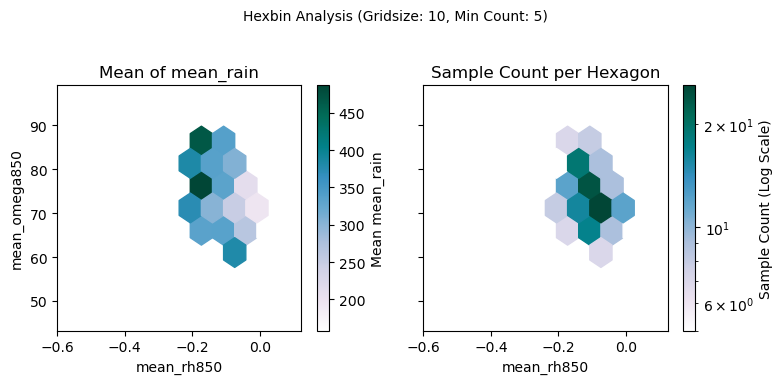

In [186]:
plot_hexbin_mean_and_count(filtered_df_rh850_scream_r2, filtered_scream_omega850[(filtered_scream_omega850.radius==radius)&(filtered_scream_omega850.time_offset_hours==0)].copy(), gridsize=10,cmap=mycmap.whiteTOblueTOgreen,mincnt=5)

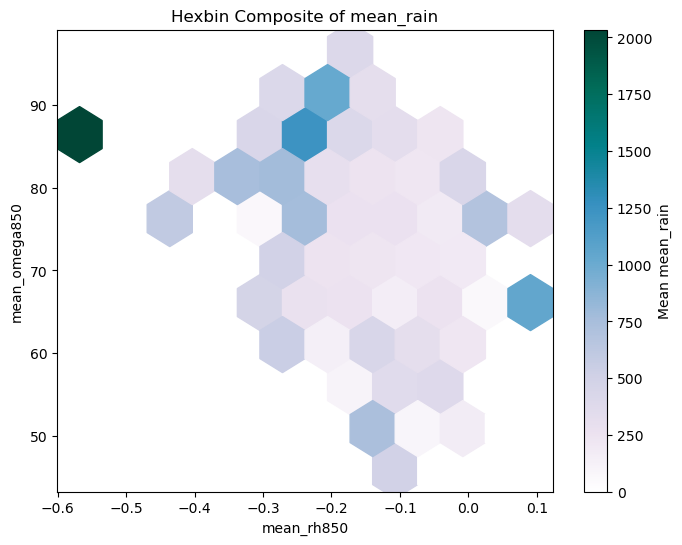

In [155]:
plot_hexbin_composite(filtered_df_rh850_scream_r2, filtered_scream_omega850[(filtered_scream_omega850.radius==radius)&(filtered_scream_omega850.time_offset_hours==0)].copy(), gridsize=10,cmap=mycmap.whiteTOblueTOgreen)

In [129]:
composite_count.sum().sum()

np.int64(259)

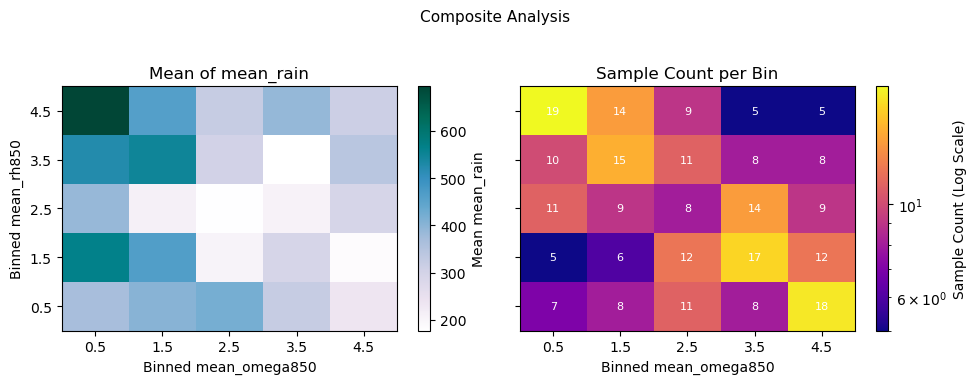

In [130]:
plot_mean_and_count_composites(composite_mean, composite_count, plot_info, cmap_mean=mycmap.whiteTOblueTOgreen)

In [157]:
filtered_scream_rh850_v2 = filtered_df_rh850_scream[filtered_df_rh850_scream['track'].isin(df_trop_scream_1ts['track_id'])]
filtered_scream_omega850_v2 = filtered_df_omega850_scream[filtered_df_omega850_scream['track'].isin(df_trop_scream_1ts['track_id'])]

In [158]:
filtered_df_rh850_scream_r2 = get_vars_per_track(filtered_scream_rh850_v2[(filtered_scream_rh850_v2.radius==radius)&(filtered_scream_rh850_v2.time_offset_hours==0)])
composite_mean, composite_count, plot_info = create_composite_grid(filtered_df_rh850_scream_r2, 
                                                                   filtered_scream_omega850_v2[(filtered_scream_omega850_v2.radius==radius)&(filtered_scream_omega850_v2.time_offset_hours==0)].copy(), 
                                                                   var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',varbins=5)


In [135]:
filtered_df_rh850_scream_r2.columns

Index(['track', 'radius', 'matched_time', 'start_basetime',
       'time_offset_hours', 'latitude', 'longitude', 'mean', 'median', 'min',
       'max', 'std', 'count', 'valid_count', 'track_duration', 'mcs_duration',
       'area', 'total_rain', 'mcs_status', 'start_split_cloudnumber',
       'time_index', 'all_rain', 'mean_rain', 'all_area'],
      dtype='object')

In [125]:
composite_count.sum().sum()

np.int64(392)

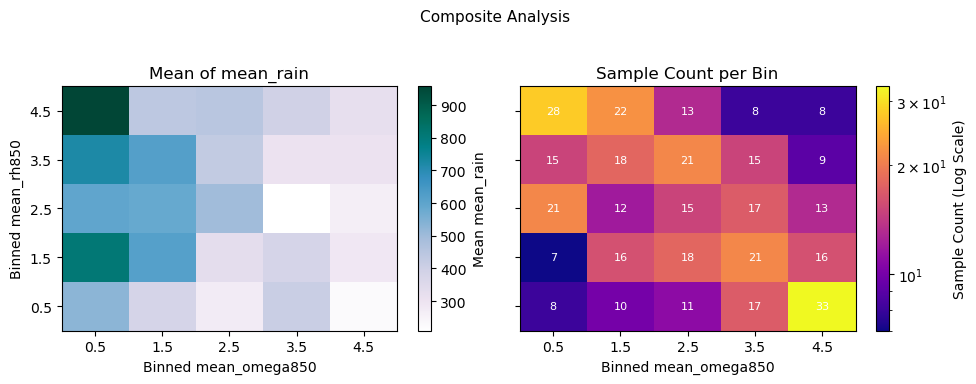

In [126]:
plot_mean_and_count_composites(composite_mean, composite_count, plot_info, cmap_mean=mycmap.whiteTOblueTOgreen)

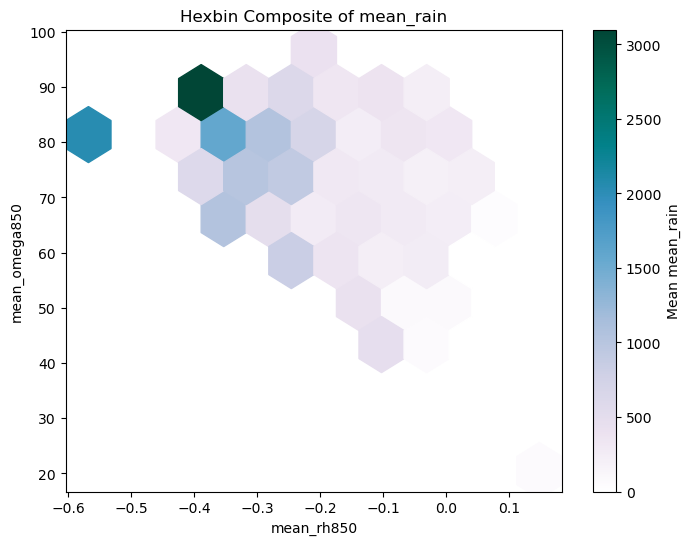

In [159]:
plot_hexbin_composite(filtered_df_rh850_scream_r2, filtered_scream_omega850_v2[(filtered_scream_omega850_v2.radius==radius)&(filtered_scream_omega850_v2.time_offset_hours==0)].copy(), gridsize=10,cmap=mycmap.whiteTOblueTOgreen)

In [131]:
radius = 2; 
filtered_df_rh850_scream_r2 = get_vars_per_track(filtered_scream_rh850_v2[(filtered_scream_rh850_v2.radius==radius)&(filtered_scream_rh850_v2.time_offset_hours==0)])
composite_scream_rh850_w850, value_feature, ft_1,ft_2 = get_composite_data(filtered_df_rh850_scream_r2.copy(),
                                                filtered_scream_omega850_v2[(filtered_scream_omega850_v2.radius==radius)&(filtered_scream_omega850_v2.time_offset_hours==0)].copy(),
                                                var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',varbins=5)

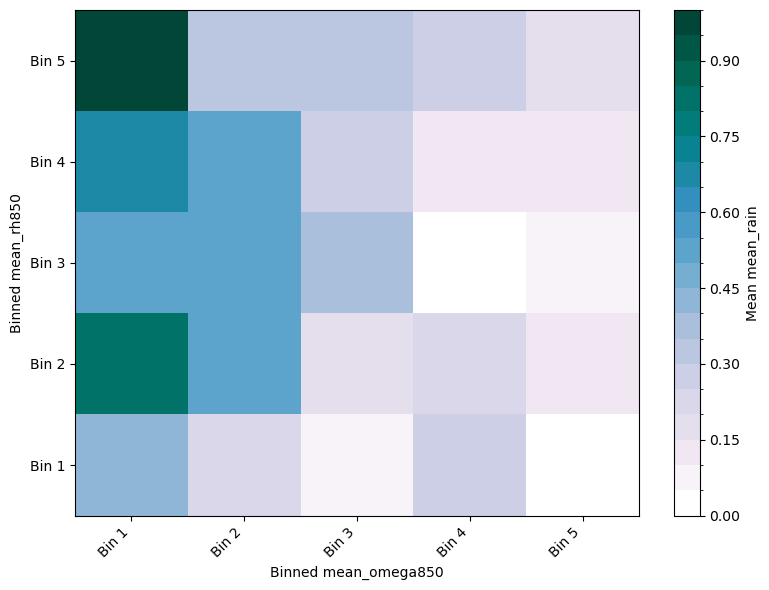

In [132]:
plot_bivariate(composite_scream_rh850_w850,value_feature,ft_1,ft_2,normalize=True,qtile_norm=False)

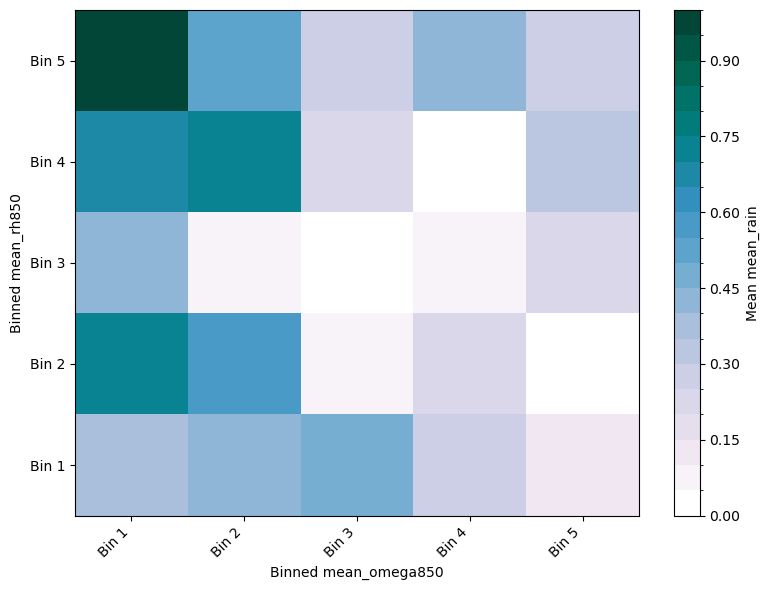

In [133]:
filtered_df_rh850_scream_r2 = get_vars_per_track(filtered_scream_rh850[(filtered_scream_rh850.radius==radius)&(filtered_scream_rh850.time_offset_hours==0)])
composite_scream_rh850_w850, value_feature, ft_1,ft_2 = get_composite_data(filtered_df_rh850_scream_r2.copy(),
                                                filtered_scream_omega850[(filtered_scream_omega850.radius==radius)&(filtered_scream_omega850.time_offset_hours==0)].copy(),
                                                var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',varbins=5)
plot_bivariate(composite_scream_rh850_w850,value_feature,ft_1,ft_2,normalize=True,qtile_norm=False)

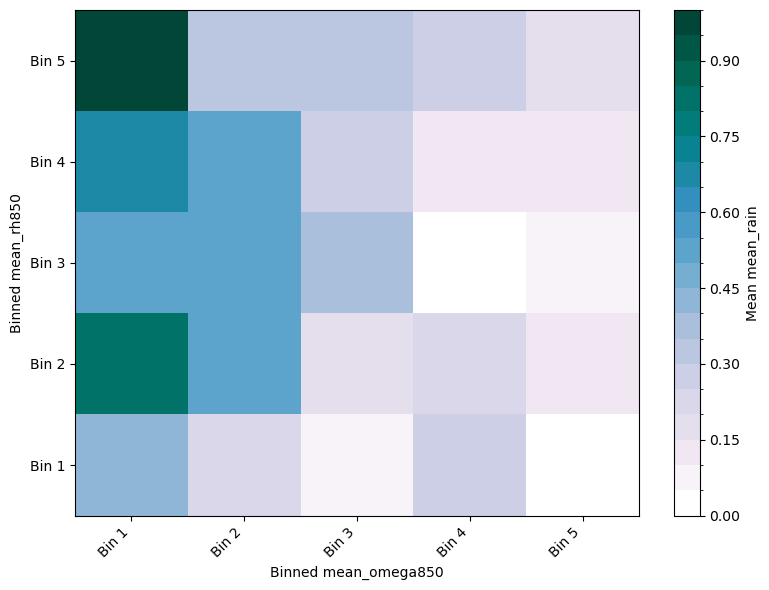

In [64]:
plot_bivariate(composite_scream_rh850_w850,value_feature,ft_1,ft_2,normalize=True,qtile_norm=False)

### UM model

In [160]:
filtered_um_rh850 = filtered_df_rh850_um[filtered_df_rh850_um['track'].isin(df_trop_um['track_id'])]
filtered_um_omega850 = filtered_df_omega850_um[filtered_df_omega850_um['track'].isin(df_trop_um['track_id'])]

filtered_um_rh850_v2 = filtered_df_rh850_um[filtered_df_rh850_um['track'].isin(df_trop_um_1ts['track_id'])]
filtered_um_omega850_v2 = filtered_df_omega850_um[filtered_df_omega850_um['track'].isin(df_trop_um_1ts['track_id'])]

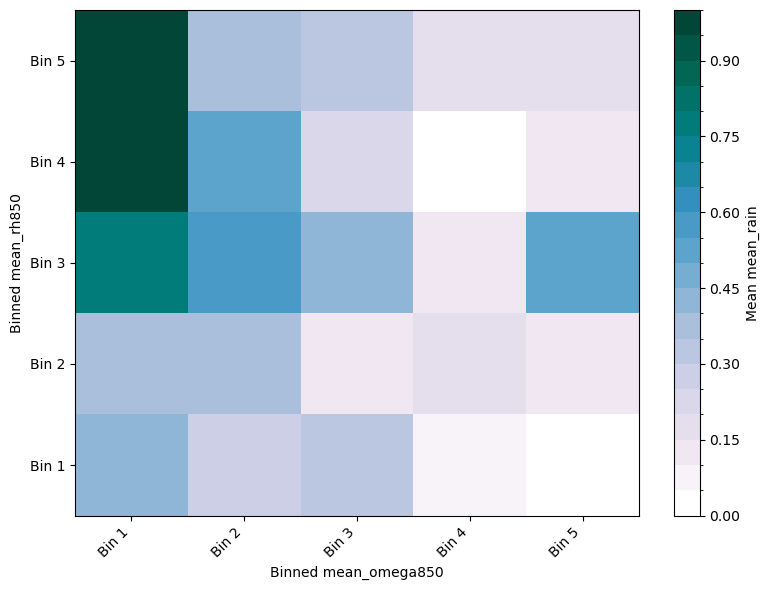

In [163]:
filtered_df_rh850_um_r2 = get_vars_per_track(filtered_um_rh850[(filtered_um_rh850.radius==radius)&(filtered_um_rh850.time_offset_hours==0)])
composite_um_rh850_w850, value_feature, ft_1,ft_2 = get_composite_data(filtered_df_rh850_um_r2.copy(),
                                                filtered_um_omega850[(filtered_um_omega850.radius==radius)&(filtered_um_omega850.time_offset_hours==0)].copy(),
                                                var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',varbins=5)
plot_bivariate(composite_um_rh850_w850,value_feature,ft_1,ft_2,normalize=True,qtile_norm=False)

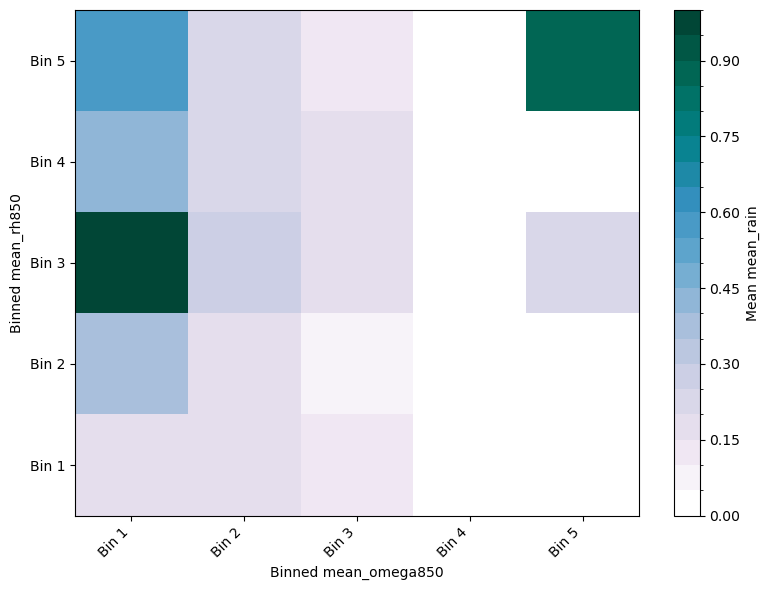

In [165]:
filtered_df_rh850_um_r2 = get_vars_per_track(filtered_um_rh850_v2[(filtered_um_rh850_v2.radius==radius)&(filtered_um_rh850_v2.time_offset_hours==0)])
composite_um_rh850_w850, value_feature, ft_1,ft_2 = get_composite_data(filtered_df_rh850_um_r2.copy(),
                                                filtered_um_omega850_v2[(filtered_um_omega850_v2.radius==radius)&(filtered_um_omega850_v2.time_offset_hours==0)].copy(),
                                                var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',varbins=5)
plot_bivariate(composite_um_rh850_w850,value_feature,ft_1,ft_2,normalize=True,qtile_norm=False)

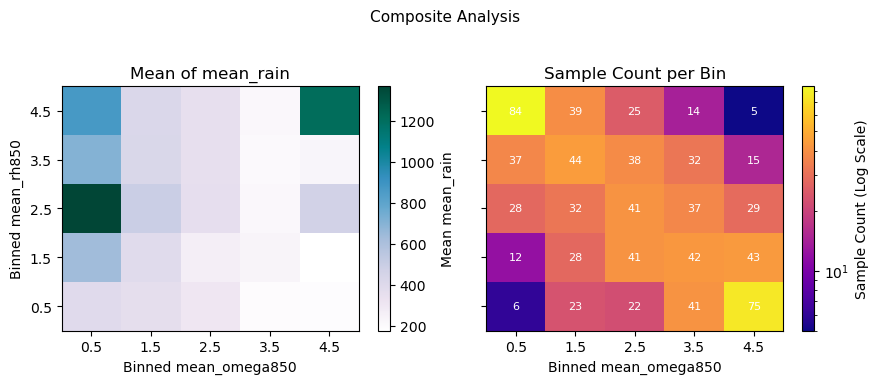

In [168]:
composite_mean, composite_count, plot_info = create_composite_grid(filtered_df_rh850_um_r2, 
                                                                   filtered_um_omega850_v2[(filtered_um_omega850_v2.radius==radius)&(filtered_um_omega850_v2.time_offset_hours==0)].copy(), 
                                                                   var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',varbins=5)
plot_mean_and_count_composites(composite_mean, composite_count, plot_info, cmap_mean=mycmap.whiteTOblueTOgreen)

### IFS model 

In [170]:
filtered_ifs_rh850 = filtered_df_rh850_ifs[filtered_df_rh850_ifs['track'].isin(df_trop_ifs['track_id'])]
filtered_ifs_omega850 = filtered_df_omega850_ifs[filtered_df_omega850_ifs['track'].isin(df_trop_ifs['track_id'])]

filtered_ifs_rh850_v2 = filtered_df_rh850_ifs[filtered_df_rh850_ifs['track'].isin(df_trop_ifs_1ts['track_id'])]
filtered_ifs_omega850_v2 = filtered_df_omega850_ifs[filtered_df_omega850_ifs['track'].isin(df_trop_ifs_1ts['track_id'])]

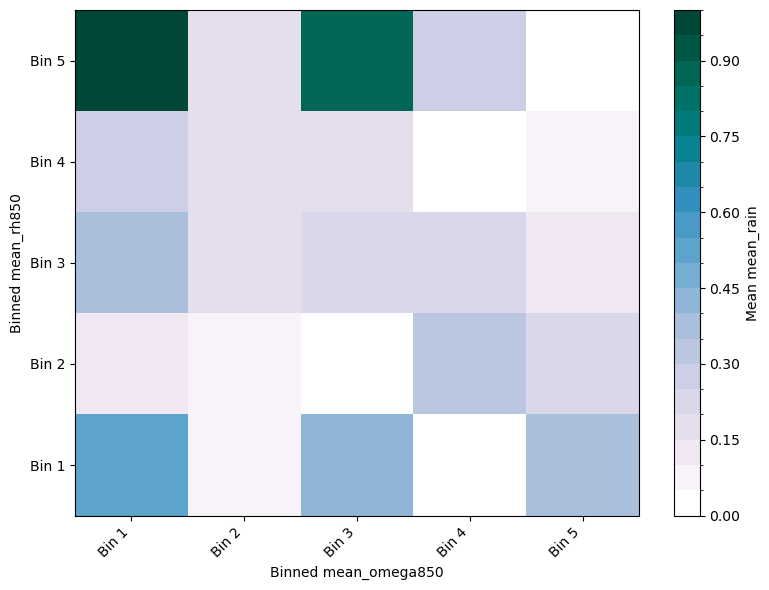

In [171]:
filtered_df_rh850_ifs_r2 = get_vars_per_track(filtered_ifs_rh850[(filtered_ifs_rh850.radius==radius)&(filtered_ifs_rh850.time_offset_hours==0)])
composite_ifs_rh850_w850, value_feature, ft_1,ft_2 = get_composite_data(filtered_df_rh850_ifs_r2.copy(),
                                                filtered_ifs_omega850[(filtered_ifs_omega850.radius==radius)&(filtered_ifs_omega850.time_offset_hours==0)].copy(),
                                                var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',varbins=5)
plot_bivariate(composite_ifs_rh850_w850,value_feature,ft_1,ft_2,normalize=True,qtile_norm=False)

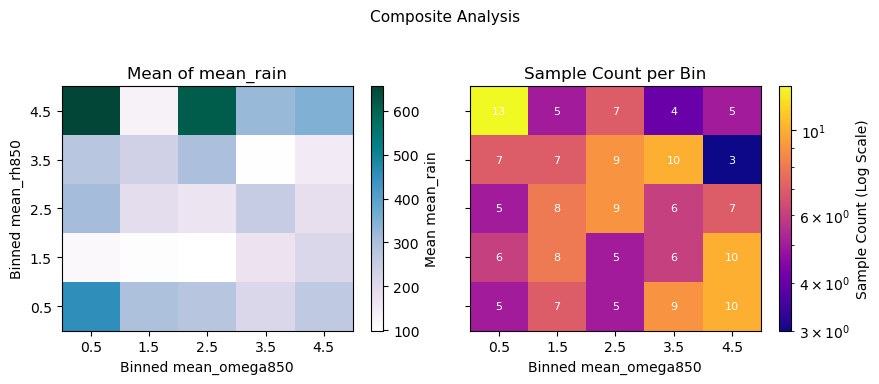

In [174]:
composite_mean, composite_count, plot_info = create_composite_grid(filtered_df_rh850_ifs_r2, 
                                                                   filtered_ifs_omega850[(filtered_ifs_omega850.radius==radius)&(filtered_ifs_omega850.time_offset_hours==0)].copy(), 
                                                                   var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',varbins=5)
plot_mean_and_count_composites(composite_mean, composite_count, plot_info, cmap_mean=mycmap.whiteTOblueTOgreen)

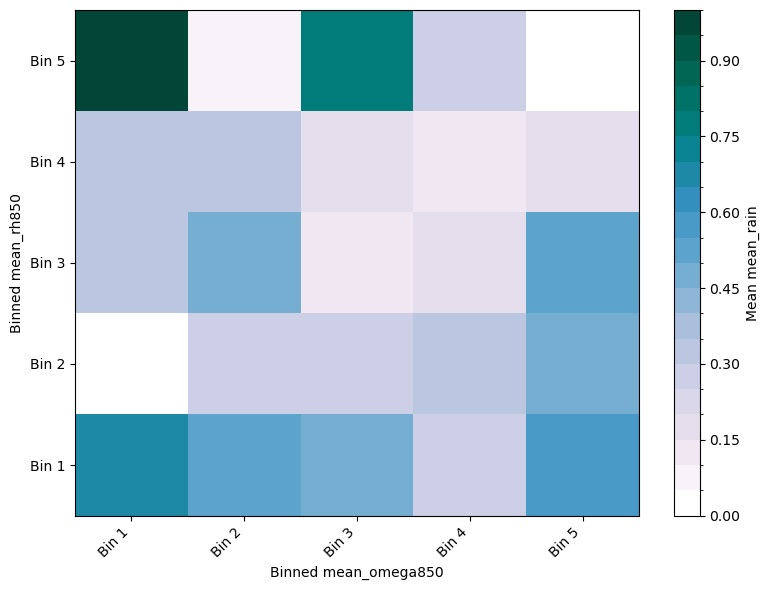

In [175]:
filtered_df_rh850_ifs_r2 = get_vars_per_track(filtered_ifs_rh850_v2[(filtered_ifs_rh850_v2.radius==radius)&(filtered_ifs_rh850_v2.time_offset_hours==0)])
composite_ifs_rh850_w850, value_feature, ft_1,ft_2 = get_composite_data(filtered_df_rh850_ifs_r2.copy(),
                                                filtered_ifs_omega850_v2[(filtered_ifs_omega850_v2.radius==radius)&(filtered_ifs_omega850_v2.time_offset_hours==0)].copy(),
                                                var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',varbins=5)
plot_bivariate(composite_ifs_rh850_w850,value_feature,ft_1,ft_2,normalize=True,qtile_norm=False)

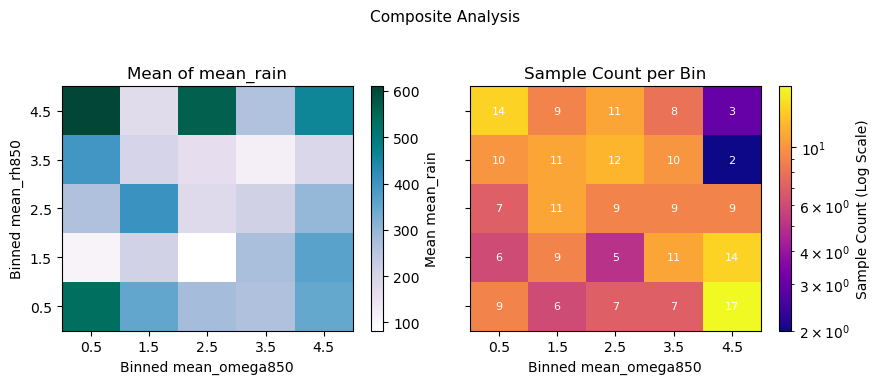

In [176]:
composite_mean, composite_count, plot_info = create_composite_grid(filtered_df_rh850_ifs_r2, 
                                                                   filtered_ifs_omega850_v2[(filtered_ifs_omega850_v2.radius==radius)&(filtered_ifs_omega850_v2.time_offset_hours==0)].copy(), 
                                                                   var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',varbins=5)
plot_mean_and_count_composites(composite_mean, composite_count, plot_info, cmap_mean=mycmap.whiteTOblueTOgreen)

In [121]:
key_cols= ['track', 'radius', 'matched_time', 'start_basetime',
            'time_offset_hours']

### ICON

In [187]:
filtered_icon_rh850 = filtered_df_rh850_icon[filtered_df_rh850_icon['track'].isin(df_trop_icon['track_id'])]
filtered_icon_omega850 = filtered_df_omega850_um[filtered_df_omega850_um['track'].isin(df_trop_icon['track_id'])]

filtered_icon_rh850_v2 = filtered_df_rh850_icon[filtered_df_rh850_icon['track'].isin(df_trop_icon_1ts['track_id'])]
filtered_icon_omega850_v2 = filtered_df_omega850_icon[filtered_df_omega850_icon['track'].isin(df_trop_icon_1ts['track_id'])]

In [138]:
filtered_df_rh850_icon_r2.time_offset_hours.unique()

array([-19, -13,  -7,  -1,   0,   6,  12,  18,  24,  30,  36,  42,  48,
        54,  60,  66,  72,  78,  84,  90,  96, 102, 108, 114, 120, 126,
       132, 138])

In [196]:
key_cols= ['track', 'radius', 
            'time_offset_hours']

In [193]:
filtered_icon_omega850[(filtered_icon_omega850.radius==radius)&(filtered_icon_omega850.time_offset_hours==0)].copy()

,track,radius,matched_time,start_basetime,time_offset_hours,latitude,longitude,mean,median,min,...,valid_count,track_duration,mcs_duration,area,total_rain,mcs_status,start_split_cloudnumber,land_fraction,time_index,pressure_level
346332,2124.0,2.0,2020-02-13 12:00:00,2020-02-13 12:00:00,0.0,5.554000,-175.714005,-0.122418,0.047346,-4.712405,...,239.0,39.0,23.0,2500.0,136.580643,0.0,NaN,0.0,0.0,850.0
379796,2759.0,2.0,2020-02-17 06:00:00,2020-02-17 06:00:00,0.0,3.592253,140.784744,-0.007545,-0.013747,-2.099066,...,239.0,17.0,9.0,21300.0,5.737640,0.0,NaN,0.0,0.0,850.0
385252,2854.0,2.0,2020-02-17 18:00:00,2020-02-17 18:00:00,0.0,-5.133333,81.687500,-0.027113,0.037305,-4.337929,...,239.0,15.0,6.0,2400.0,106.653038,0.0,NaN,0.0,0.0,850.0
388852,2916.0,2.0,2020-02-18 03:00:00,2020-02-18 03:00:00,0.0,0.105769,-31.450001,-0.150709,0.045421,-7.546328,...,239.0,29.0,9.0,5200.0,726.610046,0.0,NaN,0.0,0.0,850.0
400978,3147.0,2.0,2020-02-19 09:00:00,2020-02-19 09:00:00,0.0,12.834616,-107.342308,-0.208300,0.039403,-10.166385,...,237.0,37.0,12.0,1300.0,55.925358,0.0,NaN,0.0,0.0,850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2903776,34805.0,2.0,2021-01-15 06:00:00,2021-01-15 06:00:00,0.0,-26.891935,-119.843552,-0.057782,0.021696,-2.671231,...,236.0,10.0,5.0,3100.0,74.999596,0.0,NaN,0.0,0.0,850.0
2910434,34935.0,2.0,2021-01-16 09:00:00,2021-01-16 09:00:00,0.0,6.473333,-110.103333,-0.233352,-0.165465,-5.697750,...,239.0,26.0,12.0,3000.0,297.992767,0.0,NaN,0.0,0.0,850.0
2942902,35540.0,2.0,2021-01-21 15:00:00,2021-01-21 15:00:00,0.0,-5.104221,68.310707,-0.213427,-0.083856,-6.521643,...,239.0,24.0,12.0,30800.0,719.232971,0.0,NaN,0.0,0.0,850.0
2948476,35653.0,2.0,2021-01-22 15:00:00,2021-01-22 15:00:00,0.0,-6.391935,163.295166,-0.060878,0.027191,-5.436429,...,239.0,15.0,6.0,3100.0,201.137283,0.0,NaN,0.0,0.0,850.0


In [199]:
filtered_icon_omega850.track.nunique()

155

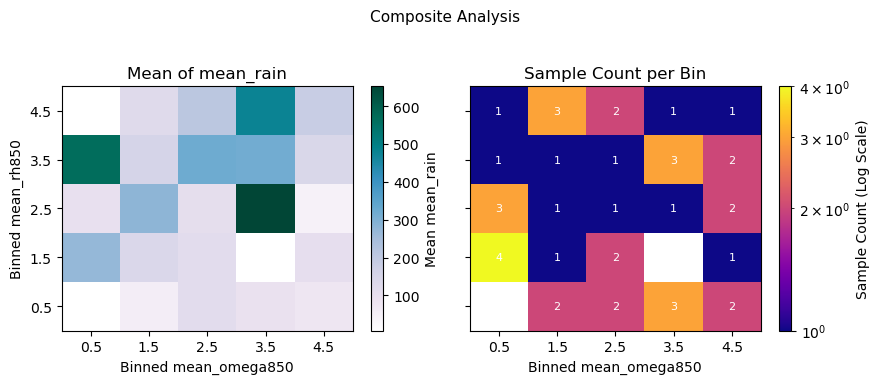

In [197]:
filtered_df_rh850_icon_r2 = get_vars_per_track(filtered_icon_rh850[(filtered_icon_rh850.radius==radius)&(filtered_icon_rh850.time_offset_hours==0)])
composite_mean, composite_count, plot_info = create_composite_grid(filtered_df_rh850_icon_r2, 
                                                                   filtered_icon_omega850[(filtered_icon_omega850.radius==radius)&(filtered_icon_omega850.time_offset_hours==0)].copy(), 
                                                                   var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',varbins=5,key_cols=key_cols)
plot_mean_and_count_composites(composite_mean, composite_count, plot_info, cmap_mean=mycmap.whiteTOblueTOgreen)

### ERA5 

In [200]:
print(len(filtered_df_prw_era5[(filtered_df_prw_era5.radius==radius)]),
      len(filtered_df_w850_era5[(filtered_df_w850_era5.radius==radius)]),
     len(filtered_df_rh850_era5[(filtered_df_rh850_era5.radius==radius)]))

406175 79819 80036


In [201]:
print((filtered_df_prw_era5.track.nunique()),
      (filtered_df_w850_era5.track.nunique()),
     filtered_df_rh500_era5.track.nunique())

17759 10074 10436


In [202]:
list_3h = filtered_df_w850_era5.rel_time_hours.unique()

In [205]:
filtered_df_rh850_era5.radius.unique()

array([0.5, 1. , 2. , 3.5])

In [206]:
filtered_era_rh850 = filtered_df_rh850_era5[filtered_df_rh850_era5['track'].isin(df_trop_obs['track_id'])]
filtered_era_w850 = filtered_df_w850_era5[filtered_df_w850_era5['track'].isin(df_trop_obs['track_id'])]

filtered_era_rh850_v2 = filtered_df_rh850_era5[filtered_df_rh850_era5['track'].isin(df_trop_obs_1ts['track_id'])]
filtered_era_w850_v2 = filtered_df_w850_era5[filtered_df_w850_era5['track'].isin(df_trop_obs_1ts['track_id'])]

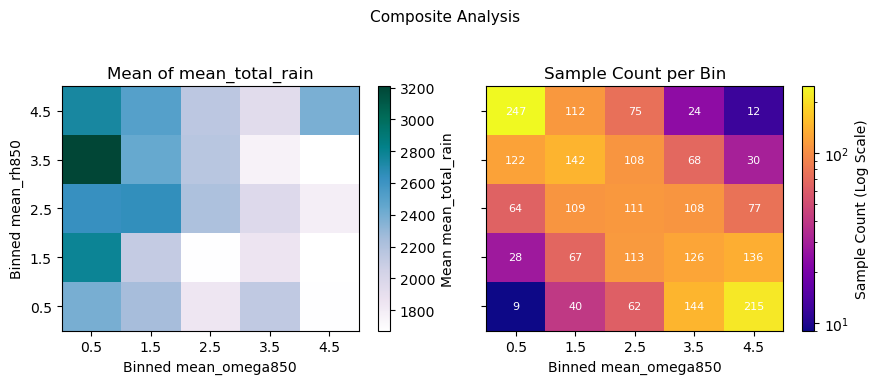

In [207]:
filtered_df_rh850_era5_r2 = filtered_era_rh850[(filtered_era_rh850['rel_time_hours'].isin(list_3h))&((filtered_era_rh850.radius==2))]


composite_mean, composite_count, plot_info = create_composite_grid(filtered_df_rh850_era5_r2[(filtered_df_rh850_era5_r2.time_offset_hours==-1)].copy(), 
                                                                   filtered_era_w850[(filtered_era_w850.radius==radius)&(filtered_era_w850.time_offset_hours==-1)].copy(), 
                                                                   var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',varbins=5,key_cols=['track'],value_feature='mean_total_rain')
plot_mean_and_count_composites(composite_mean, composite_count, plot_info, cmap_mean=mycmap.whiteTOblueTOgreen)



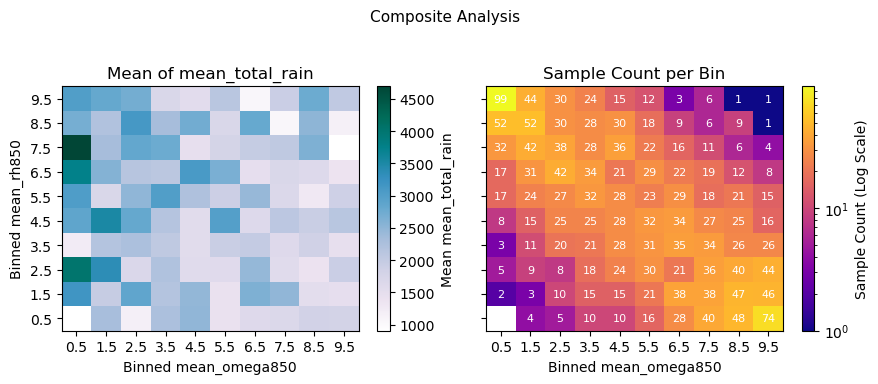

In [208]:
filtered_df_rh850_era5_r2 = filtered_era_rh850[(filtered_era_rh850['rel_time_hours'].isin(list_3h))&((filtered_era_rh850.radius==2))]


composite_mean, composite_count, plot_info = create_composite_grid(filtered_df_rh850_era5_r2[(filtered_df_rh850_era5_r2.time_offset_hours==-1)].copy(), 
                                                                   filtered_era_w850[(filtered_era_w850.radius==radius)&(filtered_era_w850.time_offset_hours==-1)].copy(), 
                                                                   var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',varbins=10,key_cols=['track'],value_feature='mean_total_rain')
plot_mean_and_count_composites(composite_mean, composite_count, plot_info, cmap_mean=mycmap.whiteTOblueTOgreen)

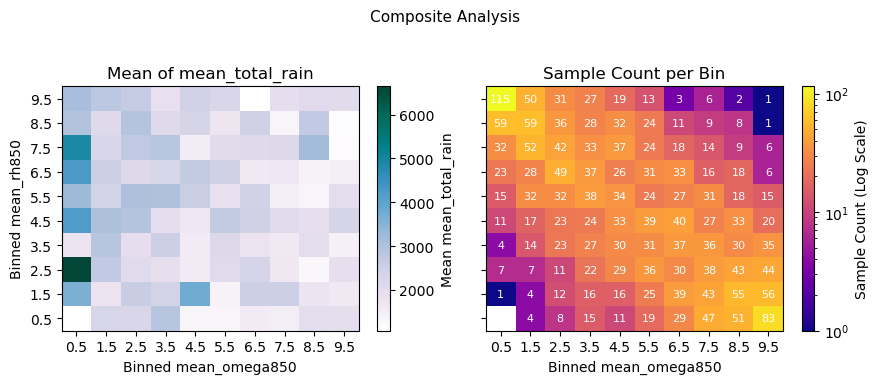

In [209]:
filtered_df_rh850_era5_r2 = filtered_era_rh850_v2[(filtered_era_rh850_v2['rel_time_hours'].isin(list_3h))&((filtered_era_rh850_v2.radius==2))]


composite_mean, composite_count, plot_info = create_composite_grid(filtered_df_rh850_era5_r2[(filtered_df_rh850_era5_r2.time_offset_hours==-1)].copy(), 
                                                                   filtered_era_w850_v2[(filtered_era_w850_v2.radius==radius)&(filtered_era_w850_v2.time_offset_hours==-1)].copy(), 
                                                                   var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',varbins=10,key_cols=['track'],value_feature='mean_total_rain')
plot_mean_and_count_composites(composite_mean, composite_count, plot_info, cmap_mean=mycmap.whiteTOblueTOgreen)

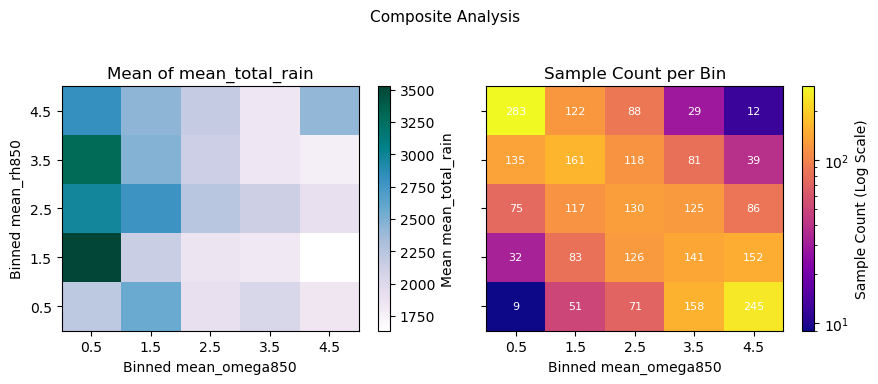

In [210]:
filtered_df_rh850_era5_r2 = filtered_era_rh850_v2[(filtered_era_rh850_v2['rel_time_hours'].isin(list_3h))&((filtered_era_rh850_v2.radius==2))]


composite_mean, composite_count, plot_info = create_composite_grid(filtered_df_rh850_era5_r2[(filtered_df_rh850_era5_r2.time_offset_hours==-1)].copy(), 
                                                                   filtered_era_w850_v2[(filtered_era_w850_v2.radius==radius)&(filtered_era_w850_v2.time_offset_hours==-1)].copy(), 
                                                                   var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',varbins=5,key_cols=['track'],value_feature='mean_total_rain')
plot_mean_and_count_composites(composite_mean, composite_count, plot_info, cmap_mean=mycmap.whiteTOblueTOgreen)

In [204]:
def get_key_stages_with_tmax(df):
    results = []

    for track_id, g in df.groupby("track"):
        g = g.sort_values("time_offset_hours")

        # 1) Mature state: nearest to time_to_max_totrain
        tmax = g["time_to_max_totrain"].iloc[0]  # same for all rows in track
        mature_idx = (g["time_offset_hours"] - tmax).abs().idxmin()
        mature_row = g.loc[mature_idx]
        mature_time = mature_row["time_offset_hours"]

        # 2) Midpoint between 0 and mature
        if (g["time_offset_hours"] >= 0).any():
            start_time = g[g["time_offset_hours"] >= 0]["time_offset_hours"].min()
        else:
            continue
        mid1_time = (start_time + mature_time) / 2
        mid1_row = g.iloc[(g["time_offset_hours"] - mid1_time).abs().argmin()]

        # 3) Midpoint between mature and termination
        end_time = g["time_offset_hours"].max()
        mid2_time = (mature_time + end_time) / 2
        mid2_row = g.iloc[(g["time_offset_hours"] - mid2_time).abs().argmin()]

        results.extend([
            {**mature_row.to_dict(), "stage": "mature"},
            {**mid1_row.to_dict(), "stage": "growing"},
            {**mid2_row.to_dict(), "stage": "decaying"},
        ])

    return pd.DataFrame(results)

In [81]:
df_rh850_sel_era5 = get_key_stages_with_tmax(filtered_df_rh850_era5[(filtered_df_rh850_era5.radius==3.5)])
df_om850_sel_era5 = get_key_stages_with_tmax(filtered_df_w850_era5[(filtered_df_w850_era5.radius==3.5)])

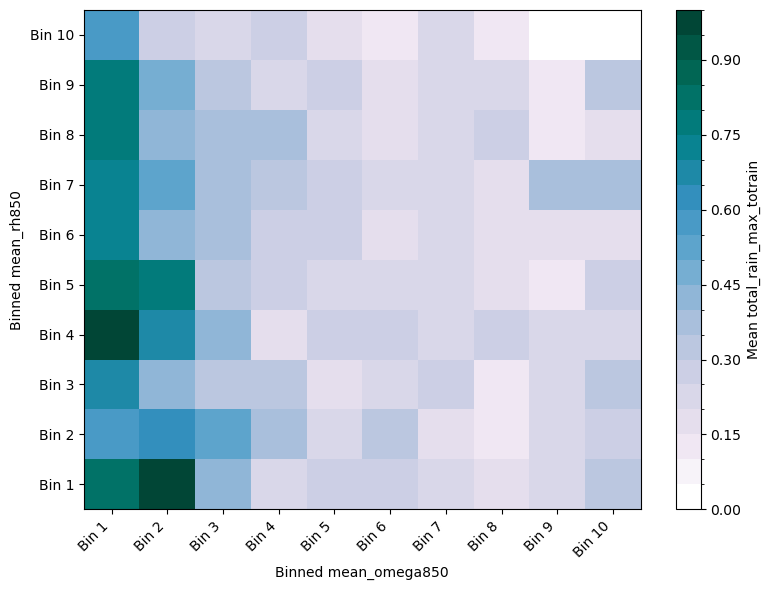

In [82]:
composite_era5_rh850_w850, value_feature, ft_1,ft_2 = get_composite_data(df_rh850_sel_era5[df_rh850_sel_era5.stage=='growing'].copy(), 
                                                                         df_om850_sel_era5[df_om850_sel_era5.stage=='growing'].copy(),
                                                var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',key_cols=['track'],
                                                                         value_feature='total_rain_max_totrain')
plot_bivariate(composite_era5_rh850_w850,value_feature,ft_1,ft_2)

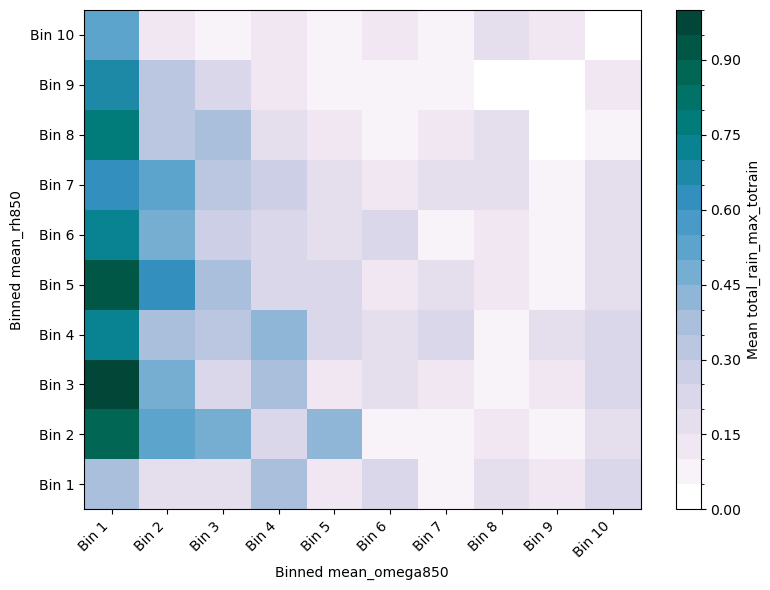

In [83]:
composite_era5_rh850_w850, value_feature, ft_1,ft_2 = get_composite_data(df_rh850_sel_era5[df_rh850_sel_era5.stage=='mature'].copy(), 
                                                                         df_om850_sel_era5[df_om850_sel_era5.stage=='mature'].copy(),
                                                var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',key_cols=['track'],
                                                                         value_feature='total_rain_max_totrain')
plot_bivariate(composite_era5_rh850_w850,value_feature,ft_1,ft_2)

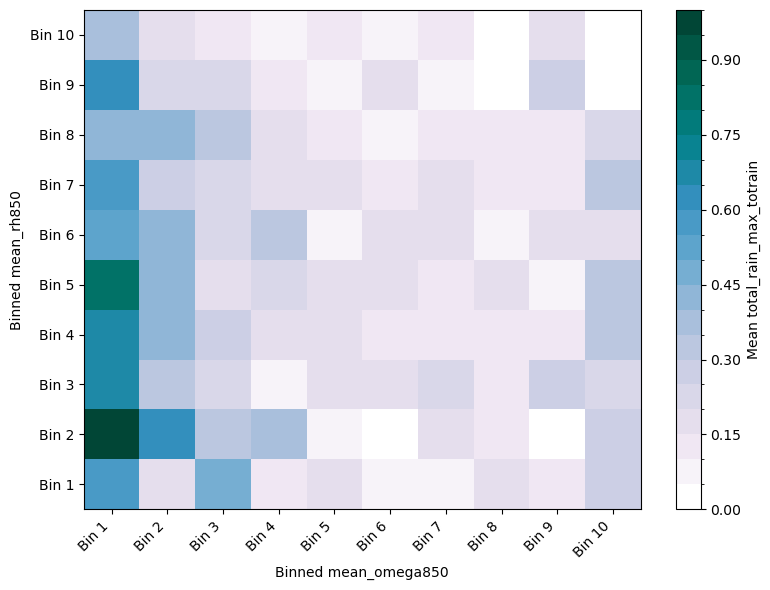

In [84]:
composite_era5_rh850_w850, value_feature, ft_1,ft_2 = get_composite_data(df_rh850_sel_era5[df_rh850_sel_era5.stage=='decaying'].copy(), 
                                                                         df_om850_sel_era5[df_om850_sel_era5.stage=='decaying'].copy(),
                                                var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',key_cols=['track'],
                                                                         value_feature='total_rain_max_totrain')
plot_bivariate(composite_era5_rh850_w850,value_feature,ft_1,ft_2)

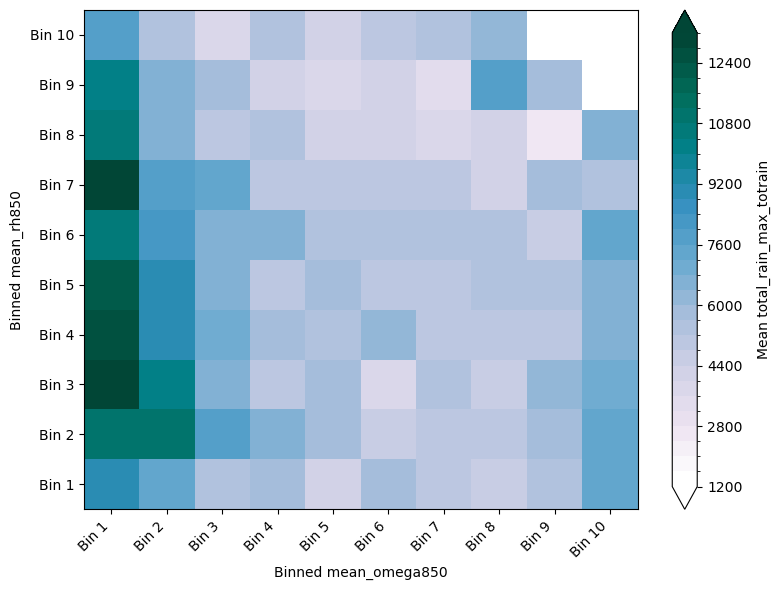

In [217]:
filtered_df_rh850_era5.time_offset_hours.unique()

array([-22., -19., -16., -13., -10.,  -7.,  -4.,  -1.,   2.,   5.,   8.,
        11.,  14.,  17.,  20.,  23.,  26.,  29.,  32.,  35.,  38.,  41.,
        44.,  47.,  50.,  53.,  56.,  59.,  62.,  65.,  68.,  71.,  74.,
        77.,  80.,  83.,  86.,  89.,  92.,  95.,  98., 101., 104., 107.,
       110., 113., 116., 119., 122., 125., 128., 131., 134., 137., 140.])

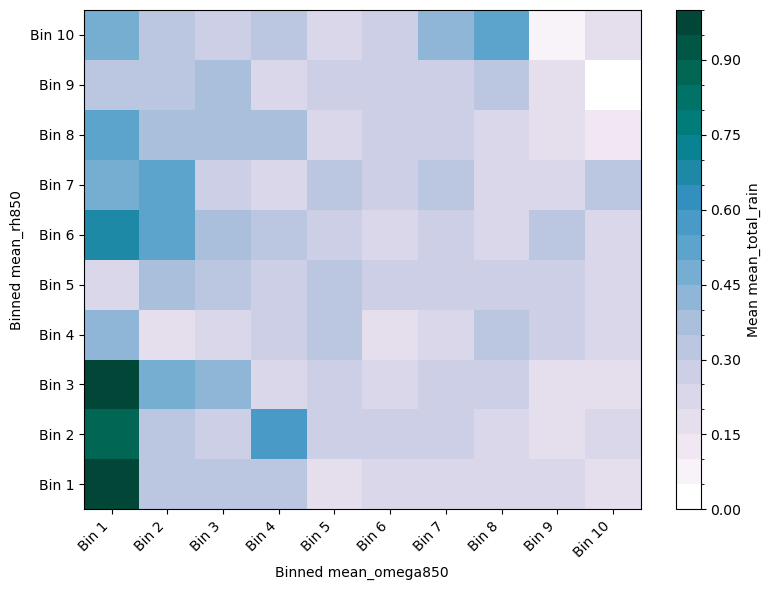

In [85]:
filtered_df_rh850_era5_r2 = filtered_df_rh850_era5[(filtered_df_rh850_era5['rel_time_hours'].isin(list_3h))&((filtered_df_rh850_era5.radius==3.5))]
composite_era5_rh850_w850, value_feature, ft_1,ft_2 = get_composite_data(filtered_df_rh850_era5_r2[(filtered_df_rh850_era5_r2.time_offset_hours==-1)].copy(),
                                                filtered_df_w850_era5[(filtered_df_w850_era5.radius==3.5)&(filtered_df_w850_era5.time_offset_hours==-1)].copy(),
                                                var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',key_cols=['track'],value_feature='mean_total_rain')
plot_bivariate(composite_era5_rh850_w850,value_feature,ft_1,ft_2)

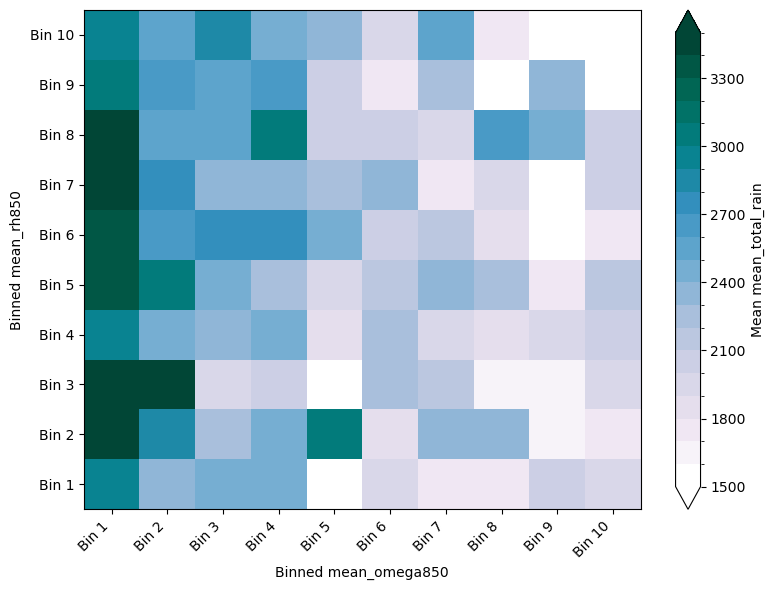

In [137]:
filtered_df_rh850_era5_r2 = filtered_df_rh850_era5[(filtered_df_rh850_era5['rel_time_hours'].isin(list_3h))&((filtered_df_rh850_era5.radius==radius))]
composite_era5_rh850_w850, value_feature, ft_1,ft_2 = get_composite_data(filtered_df_rh850_era5_r2[(filtered_df_rh850_era5_r2.time_offset_hours==-1)].copy(),
                                                filtered_df_w850_era5[(filtered_df_w850_era5.radius==radius)&(filtered_df_w850_era5.time_offset_hours==-1)].copy(),
                                                var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',key_cols=['track'],value_feature='mean_total_rain')
plot_bivariate(composite_era5_rh850_w850,value_feature,ft_1,ft_2,vmin=1500,vmax=3500,)

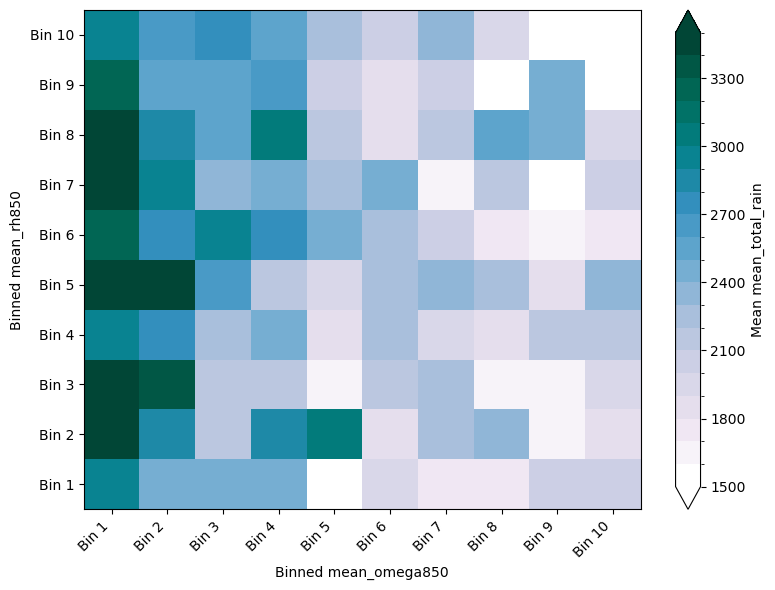

In [60]:
filtered_df_rh850_era5_r2 = filtered_df_rh850_era5[(filtered_df_rh850_era5['rel_time_hours'].isin(list_3h))&((filtered_df_rh850_era5.radius==radius))]
composite_era5_rh850_w850, value_feature, ft_1,ft_2 = get_composite_data(filtered_df_rh850_era5_r2[(filtered_df_rh850_era5_r2.time_offset_hours==-1)].copy(),
                                                filtered_df_w850_era5[(filtered_df_w850_era5.radius==radius)&(filtered_df_w850_era5.time_offset_hours==-1)].copy(),
                                                var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',key_cols=['track'],value_feature='mean_total_rain')
plot_bivariate(composite_era5_rh850_w850,value_feature,ft_1,ft_2,vmin=1500,vmax=3500,)

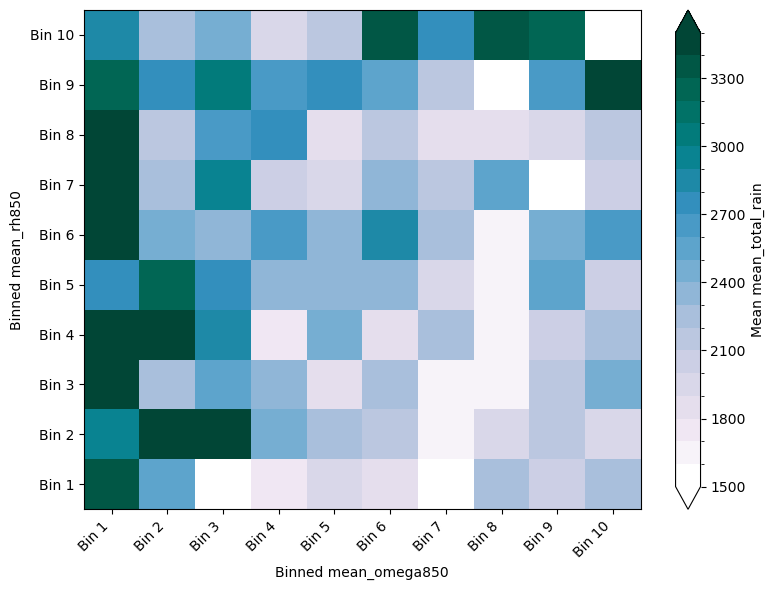

In [63]:
filtered_df_rh850_era5_r2 = filtered_df_rh850_era5[(filtered_df_rh850_era5['rel_time_hours'].isin(list_3h))&((filtered_df_rh850_era5.radius==radius))]
composite_era5_rh850_w850, value_feature, ft_1,ft_2 = get_composite_data(filtered_df_rh850_era5_r2[(filtered_df_rh850_era5_r2.time_offset_hours==-4)].copy(),
                                                filtered_df_w850_era5[(filtered_df_w850_era5.radius==radius)&(filtered_df_w850_era5.time_offset_hours==-4)].copy(),
                                                var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',key_cols=['track'],value_feature='mean_total_rain')
plot_bivariate(composite_era5_rh850_w850,value_feature,ft_1,ft_2,vmin=1500,vmax=3500,)

In [67]:
filtered_df_rh850_era5.columns

Index(['track', 'rel_time_hours', 'radius', 'variable', 'longitude',
       'latitude', 'land_fraction', 'track_duration', 'mean', 'median', 'min',
       'max', 'std', 'count', 'mean_area', 'total_area', 'mean_total_rain',
       'all_total_rain', 'time_offset_hours'],
      dtype='object')

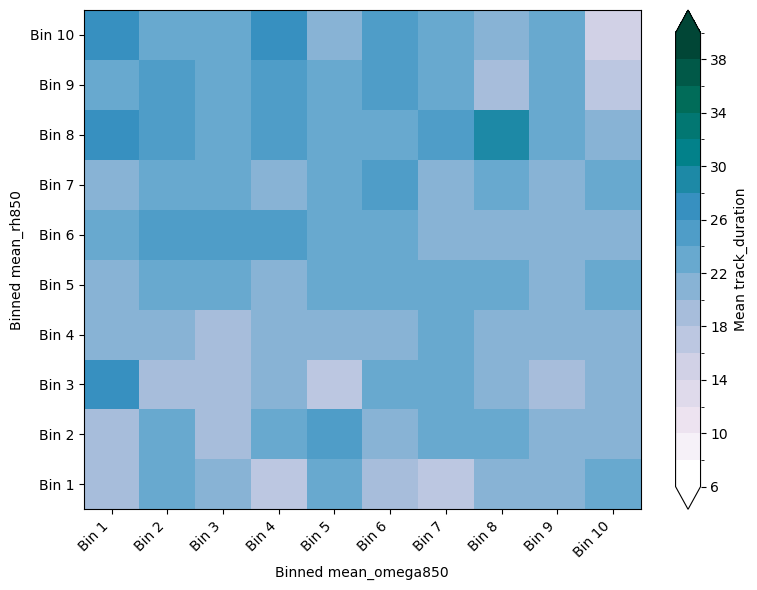

In [77]:
filtered_df_rh850_era5_r2 = filtered_df_rh850_era5[(filtered_df_rh850_era5['rel_time_hours'].isin(list_3h))&((filtered_df_rh850_era5.radius==radius))]
composite_era5_rh850_w850, value_feature, ft_1,ft_2 = get_composite_data(filtered_df_rh850_era5_r2[(filtered_df_rh850_era5_r2.time_offset_hours==-1)].copy(),
                                                filtered_df_w850_era5[(filtered_df_w850_era5.radius==radius)&(filtered_df_w850_era5.time_offset_hours==-1)].copy(),
                                                var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',key_cols=['track'],value_feature='track_duration')
plot_bivariate(composite_era5_rh850_w850,value_feature,ft_1,ft_2,vmin=7,vmax=40,)

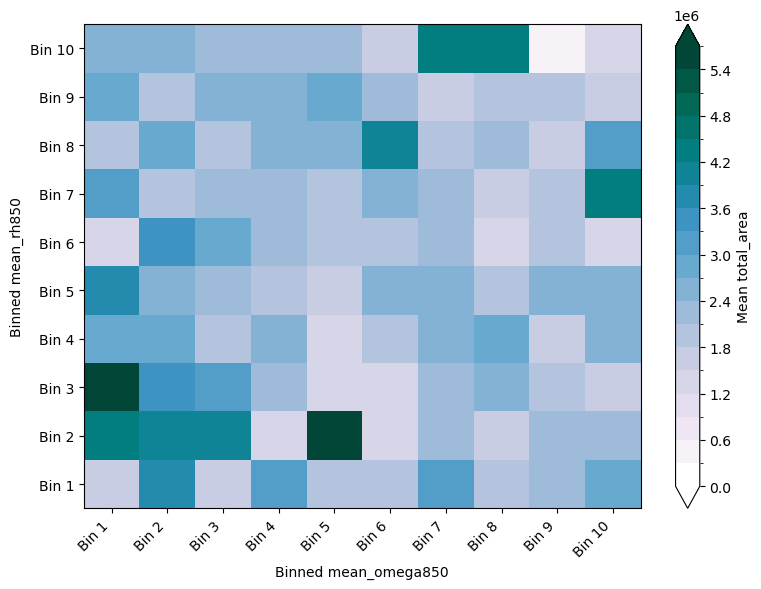

In [80]:
filtered_df_rh850_era5_r2 = filtered_df_rh850_era5[(filtered_df_rh850_era5['rel_time_hours'].isin(list_3h))&((filtered_df_rh850_era5.radius==radius))]
composite_era5_rh850_w850, value_feature, ft_1,ft_2 = get_composite_data(filtered_df_rh850_era5_r2[(filtered_df_rh850_era5_r2.time_offset_hours==-7)].copy(),
                                                filtered_df_w850_era5[(filtered_df_w850_era5.radius==radius)&(filtered_df_w850_era5.time_offset_hours==-7)].copy(),
                                                var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',key_cols=['track'],value_feature='total_area')
plot_bivariate(composite_era5_rh850_w850,value_feature,ft_1,ft_2,vmin=10000,vmax=5500000)

In [22]:
# 
# del(df_test_era)

# df_test_era = filtered_df_rh500_era5[(filtered_df_rh500_era5.radius==radius)&(
#     filtered_df_rh500_era5['mean']>0)].copy()
# df_test_era = filtered_df_rh850_era5[(filtered_df_rh850_era5.radius==radius)&(
#     filtered_df_rh850_era5['mean']>0)].copy()
df_test_era.columns

Index(['index', 'track', 'rel_time_hours', 'radius', 'variable', 'longitude',
       'latitude', 'land_fraction', 'track_duration', 'mean', 'median', 'min',
       'max', 'std', 'count', 'time_offset_hours'],
      dtype='object')

In [23]:
df_subset_era = df_test_era[df_test_era['rel_time_hours'].isin(list_3h)]

In [24]:
df_subset_era = df_subset_era[df_subset_era.time_offset_hours<0]
df_test_w850_era = filtered_df_w850_era5[(filtered_df_w850_era5.radius==radius)&(filtered_df_w850_era5.time_offset_hours<0)].copy()

In [25]:
df_test_w850_era.columns

Index(['track', 'rel_time_hours', 'radius', 'variable', 'longitude',
       'latitude', 'land_fraction', 'track_duration', 'mean', 'median', 'min',
       'max', 'std', 'count', 'mean_area', 'total_area', 'mean_total_rain',
       'all_total_rain', 'time_offset_hours'],
      dtype='object')

In [26]:
df_subset_era.columns

Index(['index', 'track', 'rel_time_hours', 'radius', 'variable', 'longitude',
       'latitude', 'land_fraction', 'track_duration', 'mean', 'median', 'min',
       'max', 'std', 'count', 'time_offset_hours'],
      dtype='object')

In [27]:
print(df_test_w850_era.track.nunique(),df_subset_era.track.nunique())

5226 8885


In [28]:
df_test_w850_era = df_test_w850_era.rename(columns={"mean": "mean_w850"})

In [29]:
df_subset_era = df_subset_era.rename(columns={"mean": "mean_prw"})
# df_subset_era = df_subset_era.rename(columns={"mean": "mean_rh500"})

In [32]:
key_cols = ['track', 'radius', 'rel_time_hours', 'track_duration',
            'time_offset_hours', 'mean_area', 'total_area', 'mean_total_rain',
       'all_total_rain',]

key_cols2 = ['track', 'radius','track_duration',
            'time_offset_hours', ]

In [54]:
# df_test_w850_era['all_rain'] = df_test_w850_era.groupby('track')['total_rain'].transform('sum')
# df_test_w850_era['mean_rain'] = df_test_w850_era.groupby('track')['total_rain'].transform('mean')
# df_test_w850_era['all_area'] = df_test_w850_era.groupby('track')['area'].transform('sum')

In [55]:
print(len(df_subset_era),len(df_test_w850_era))

71080 41808


In [34]:
# del(final_df_era)
# final_df_era = df_subset_era.merge(
#     df_test_w850_era[key_cols + ['mean_w850']], 
#     on=key_cols, 
#     how='left'
# )

final_df_era = df_test_w850_era.merge(
    df_subset_era[['track','mean_prw']], 
    on='track', 
    how='left'
)



In [35]:
final_df_era.track.unique()

array([    0,     2,     3, ..., 32116, 32128, 32131], shape=(5226,))

In [36]:
# final_df_era = pd.merge(
#         df_test_w850_era,
#         df_subset_era,
#         on='track',
#         how='inner' # Keeps only records with matching track IDs in both tables
#     )

In [37]:
final_df_era.track.nunique()

5226

In [38]:
final_df_era.time_offset_hours.unique()

array([-22., -19., -16., -13., -10.,  -7.,  -4.,  -1.])

In [39]:
# feature_1 = 'mean_w850'; num_bins = 10; 
# bin_labels_1 = [f'Bin {i+1}' for i in range(num_bins)]
# final_df_era[f'{feature_1}_bin'] = pd.qcut(final_df_era[feature_1], q=num_bins, labels=bin_labels_1, duplicates='drop')
# bins_for_labels_1 = pd.qcut(final_df_era[feature_1], q=num_bins, duplicates='drop').cat.categories
feature_1 = 'mean_w850'; num_bins = 10; 
bin_labels_1 = [f'Bin {i+1}' for i in range(num_bins)]
final_df_era[f'{feature_1}_bin'] = pd.qcut(final_df_era[feature_1], q=num_bins, labels=bin_labels_1, duplicates='drop')
bins_for_labels_1 = pd.qcut(final_df_era[feature_1], q=num_bins, duplicates='drop').cat.categories

feature_2 = 'mean_prw'; num_bins = 10; 
# feature_2 = 'mean_rh500'; num_bins = 10; 
bin_labels_2 = [f'Bin {i+1}' for i in range(num_bins)]
final_df_era[f'{feature_2}_bin'] = pd.qcut(final_df_era[feature_2], q=num_bins, labels=bin_labels_2, duplicates='drop')
bins_for_labels_2 = pd.qcut(final_df_era[feature_2], q=num_bins, duplicates='drop').cat.categories

In [40]:
feature_2

'mean_prw'

In [41]:
bins_for_labels_1

IntervalIndex([   (-0.905, -0.198],    (-0.198, -0.143],    (-0.143, -0.111],
                 (-0.111, -0.0869],  (-0.0869, -0.0647],  (-0.0647, -0.0446],
                 (-0.0446, -0.024], (-0.024, -0.000161], (-0.000161, 0.0322],
                   (0.0322, 0.552]],
              dtype='interval[float64, right]')

In [42]:
bins_for_labels_2

IntervalIndex([(12.292, 42.534],  (42.534, 48.28],  (48.28, 51.214],
               (51.214, 53.172], (53.172, 54.729], (54.729, 56.128],
               (56.128, 57.475], (57.475, 58.903], (58.903, 60.826],
               (60.826, 71.846]],
              dtype='interval[float64, right]')

In [43]:
final_df_era.columns

Index(['track', 'rel_time_hours', 'radius', 'variable', 'longitude',
       'latitude', 'land_fraction', 'track_duration', 'mean_w850', 'median',
       'min', 'max', 'std', 'count', 'mean_area', 'total_area',
       'mean_total_rain', 'all_total_rain', 'time_offset_hours', 'mean_prw',
       'mean_w850_bin', 'mean_prw_bin'],
      dtype='object')

In [39]:
final_df_era[final_df_era.track==32131][['track','mean_total_rain_y','mean_total_rain_x',
               'rel_time_hours_x','rel_time_hours_y']]

,track,mean_total_rain_y,mean_total_rain_x,rel_time_hours_x,rel_time_hours_y
1170211,32131,770.532104,770.532104,-22.0,-22.0
1170212,32131,770.532104,770.532104,-22.0,-19.0
1170213,32131,770.532104,770.532104,-22.0,-16.0
1170214,32131,770.532104,770.532104,-22.0,-13.0
1170215,32131,770.532104,770.532104,-22.0,-10.0
...,...,...,...,...,...
1170306,32131,770.532104,770.532104,5.0,-7.0
1170307,32131,770.532104,770.532104,5.0,-4.0
1170308,32131,770.532104,770.532104,5.0,-1.0
1170309,32131,770.532104,770.532104,5.0,2.0


In [44]:
value_feature = 'mean_total_rain'
composite_data = final_df_era.groupby([f'{feature_1}_bin',f'{feature_2}_bin'])[value_feature].mean().unstack()

In [44]:
composite_data.T

mean_w850_bin,Bin 1,Bin 2,Bin 3,Bin 4,Bin 5,Bin 6,Bin 7,Bin 8,Bin 9,Bin 10
mean_rh850_bin,,,,,,,,,,
Bin 1,2922.318359,3381.559570,2526.642090,2316.071289,2275.313721,2522.321045,2317.001221,2205.796143,2129.471436,2488.556152
Bin 2,2830.210205,2703.418701,2347.479492,2104.941650,2251.215576,2196.834229,2103.700684,2100.838623,2061.145264,2318.240723
Bin 3,3411.631836,2732.404541,3035.750732,2329.966797,2064.631104,1976.043091,2038.265381,2005.751709,2112.053711,2194.057861
Bin 4,4626.463379,2831.035156,2323.828857,2275.549072,2156.541992,2097.532227,2202.427490,2167.665039,2192.599854,2131.588135
Bin 5,3475.032227,2450.027100,2047.822876,2245.684326,1910.393921,2179.319092,2237.065918,2050.225098,2198.840576,2415.941895
Bin 6,3304.438232,2884.728027,2508.401367,2584.436523,2281.439453,2139.551270,2260.016113,2453.302246,2367.848877,2400.971924
Bin 7,2910.326904,2534.708984,2370.709473,2347.688721,2534.072021,2350.420898,2181.478027,2443.892822,2322.888672,3032.412842
Bin 8,2627.341309,2427.732910,2454.772949,2312.397461,2295.822998,2332.503906,2297.485596,2332.563232,2252.345459,3061.831055
Bin 9,2795.310059,2684.973145,2411.211426,2350.182617,2395.240967,2202.142334,2540.063477,2539.129639,2806.412598,3190.459961


In [45]:
composite_data.T

mean_w850_bin,Bin 1,Bin 2,Bin 3,Bin 4,Bin 5,Bin 6,Bin 7,Bin 8,Bin 9,Bin 10
mean_rh500_bin,,,,,,,,,,
Bin 1,3300.096680,3060.636230,2703.077148,2289.687744,2371.242920,2377.721436,2586.808105,2714.970947,2343.210205,2459.540283
Bin 2,3073.391357,2623.112549,2679.769775,2562.817383,2391.841553,2047.029907,2266.592529,2178.403076,2283.522705,2262.312256
Bin 3,2498.024414,2486.313965,2219.796387,2143.029785,2026.765137,2168.135742,2180.365234,2260.613770,2094.104980,2278.562012
Bin 4,2682.410400,2501.400635,2324.104004,2292.020264,2157.249756,2139.909424,2071.347412,1967.321777,2019.291870,2125.927246
Bin 5,2328.438965,2363.262939,2343.656494,2205.100342,1951.508301,2150.650879,2254.216797,2064.531982,1977.746704,2668.633789
Bin 6,2495.881348,2688.867432,2291.713867,2260.574219,2399.843750,2188.366699,2007.824341,2098.366211,2030.175659,2335.745850
Bin 7,2435.848877,2252.968262,2351.836914,2346.986572,2130.569092,2060.057129,2284.662842,1869.601929,2014.625977,2006.516602
Bin 8,2855.149902,2548.538330,2293.186768,2183.355957,2189.668701,2066.462646,2142.891357,2104.600342,2263.682373,2250.179443
Bin 9,2738.796631,2625.375244,2648.306152,2499.908447,2242.861328,2187.369141,2182.894775,2151.472900,2225.141113,2345.642822


In [46]:
composite_data.T

mean_w850_bin,Bin 1,Bin 2,Bin 3,Bin 4,Bin 5,Bin 6,Bin 7,Bin 8,Bin 9,Bin 10
mean_prw_bin,,,,,,,,,,
Bin 1,5085.599609,4284.605469,3774.753906,3237.817383,3210.964844,3039.626709,3205.864014,3098.792969,2777.879639,3153.959961
Bin 2,3816.235352,2808.967773,2562.512939,2338.613525,2308.684814,2155.829102,2260.585693,2217.336670,2069.294434,2435.951904
Bin 3,2755.998779,2463.179443,2162.373535,2099.744385,1999.191406,1938.411377,1955.982788,1971.588745,1803.292114,2027.535400
Bin 4,2683.826904,2351.905273,2145.661133,2124.344482,2067.216797,1933.663940,1904.690552,1909.022583,1814.448853,1884.386230
Bin 5,2301.622803,2201.947998,2080.605225,2093.059082,2059.087158,2074.537598,2025.265259,2014.080688,2096.824707,2164.023682
Bin 6,2296.415527,2336.168945,2255.278809,2263.786377,2004.068604,2124.357666,2025.442383,2037.735107,2084.293457,2111.470703
Bin 7,2142.841553,2193.551514,2114.947754,2206.647461,1981.880371,2038.768677,2087.753174,2011.223022,2030.236206,2020.308838
Bin 8,2134.519775,2392.928711,2437.297607,2270.676270,2174.257324,2198.899170,2211.576660,2173.515381,2249.459961,2194.584229
Bin 9,2302.534668,2361.082764,2397.021973,2314.323730,2291.562256,2215.861816,2230.097656,2112.577148,2136.687988,2342.014404


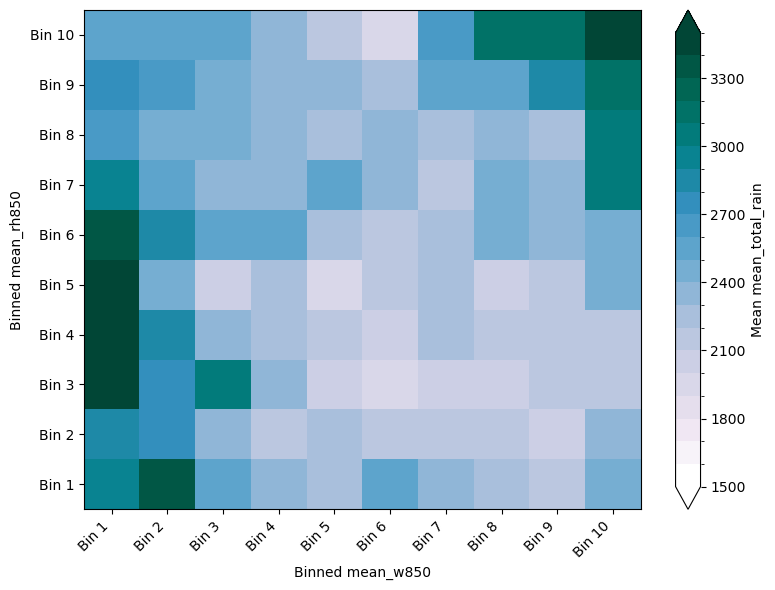

In [52]:
plot_bivariate(composite_data.T,value_feature,feature_1,feature_2,vmin=1500,vmax=3500,nbins=20)

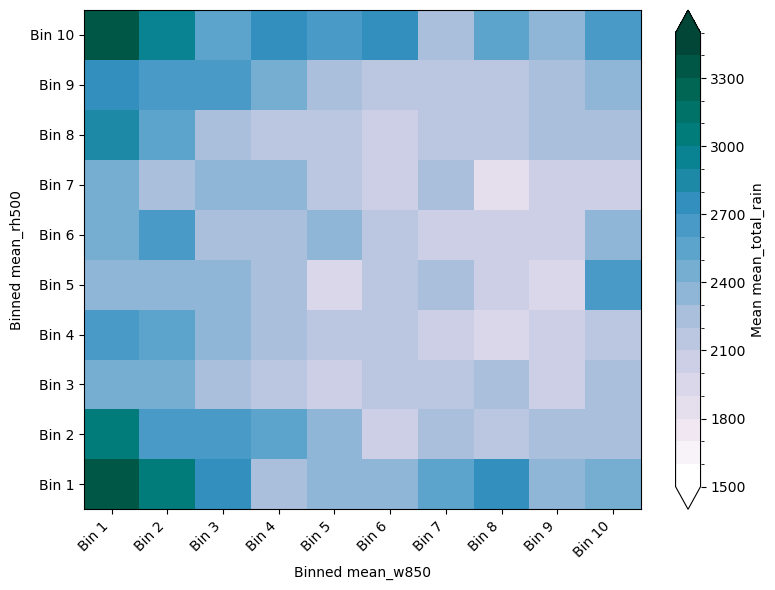

In [44]:
plot_bivariate(composite_data.T,value_feature,feature_1,feature_2,vmin=1500,vmax=3500,nbins=20)

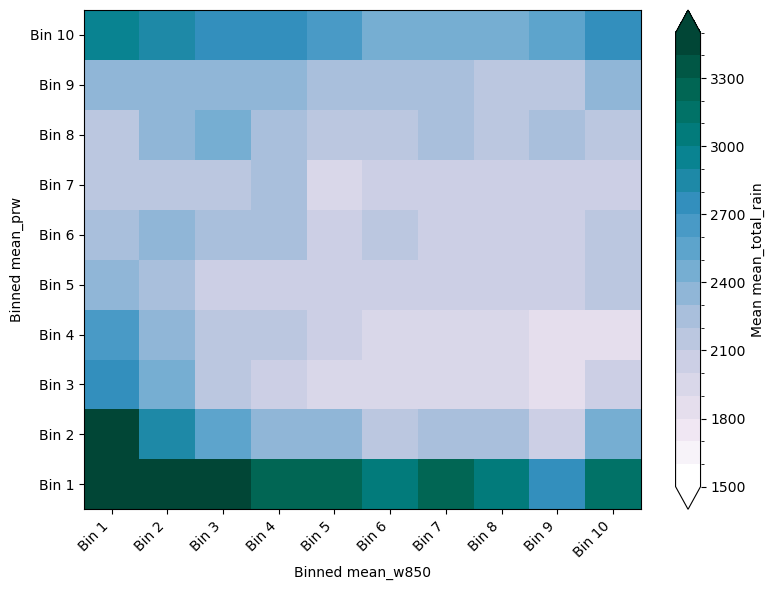

In [47]:
plot_bivariate(composite_data.T,value_feature,feature_1,feature_2,vmin=1500,vmax=3500,nbins=20)